Broad sections of code -
1. settings correct parameters that give binary decision type fixed states
2. visualise the nullclines on the 1-1 axis
3. let the activity settle to baseline and then provide stimulus
4. check the difference between activity before and after stimulus, for proper memory retention the difference should be non-zero
5. plasticity parameters (somebody else can add what we need to do here, i am a little foggy)
6. (bonus) use static transfer function to see how nullclines change vs how the plasticity parameters
7. defining stability and flexibility well *
8. look at plots and heatmaps around the values where changes happen, and take care of units of time etc.


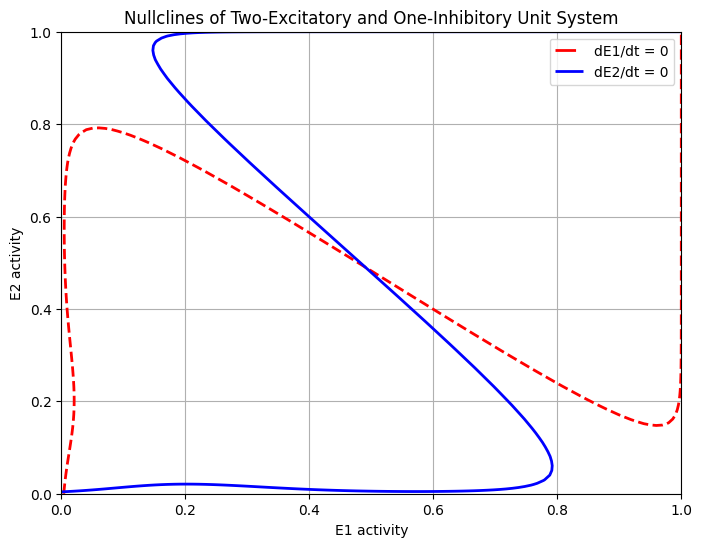

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x, beta=1.0, theta=0.0):
    return 1 / (1 + np.exp(-beta * (x - theta)))

beta = 5.0  # Steepness of the sigmoid
theta = 0.4  # Threshold of the sigmoid
tau = 0.1  # Time constant for excitatory units

# External inputs to E1, E2, and I units
I_ext_E1 = 0.0
I_ext_E2 = 0.0
I_ext_I = 0.0  # inhibition assumed instantaneous which means its response is dependent on E1 and E2

# Connection weights
w_EE = 6.2   # stronger self- and cross-excitation
w_IE = 1.0    # E→I (strong input to inhibition)
w_EI = 6.0    # I→E (strong inhibition to enforce competition)

E1_vals = np.linspace(0, 1, 100)
E2_vals = np.linspace(0, 1, 100)
E1_grid, E2_grid = np.meshgrid(E1_vals, E2_vals)

# Instantaneous inhibitory activity
def inhibitory_activity(E1, E2):
    return sigmoid(w_IE * (E1 + E2), beta, theta)

# Compute dE1/dt and dE2/dt - the attractor model differential equations - the dynamics of the system - Wilson-Cowan model
def dE_dt(E1, E2, I):
    dE1 = -E1 + sigmoid(w_EE * E1 + w_EE * E2 - w_EI * I + I_ext_E1, beta, theta)
    dE2 = -E2 + sigmoid(w_EE * E2 + w_EE * E1 - w_EI * I + I_ext_E2, beta, theta)
    return dE1, dE2

# nullclines are when differentials are equal to zero
dE1_nullcline = np.zeros_like(E1_grid)
dE2_nullcline = np.zeros_like(E2_grid)

lis_I = []
for i in range(E1_grid.shape[0]):
    for j in range(E1_grid.shape[1]):
        E1 = E1_grid[i, j]
        E2 = E2_grid[i, j]
        I = inhibitory_activity(E1, E2)
        lis_I.append(I)
        dE1, dE2 = dE_dt(E1, E2, I)
        dE1_nullcline[i, j] = dE1
        dE2_nullcline[i, j] = dE2

plt.figure(figsize=(8, 6))
contour1 = plt.contour(E1_grid, E2_grid, dE1_nullcline, levels=[0], colors='r', linestyles='--', linewidths=2)
contour2 = plt.contour(E1_grid, E2_grid, dE2_nullcline, levels=[0], colors='b', linestyles='-', linewidths=2)
plt.title('Nullclines of Two-Excitatory and One-Inhibitory Unit System')
plt.xlabel('E1 activity')
plt.ylabel('E2 activity')
plt.legend(handles=[contour1.legend_elements()[0][0], contour2.legend_elements()[0][0]], labels=['dE1/dt = 0', 'dE2/dt = 0'])
plt.grid(True)
plt.show()

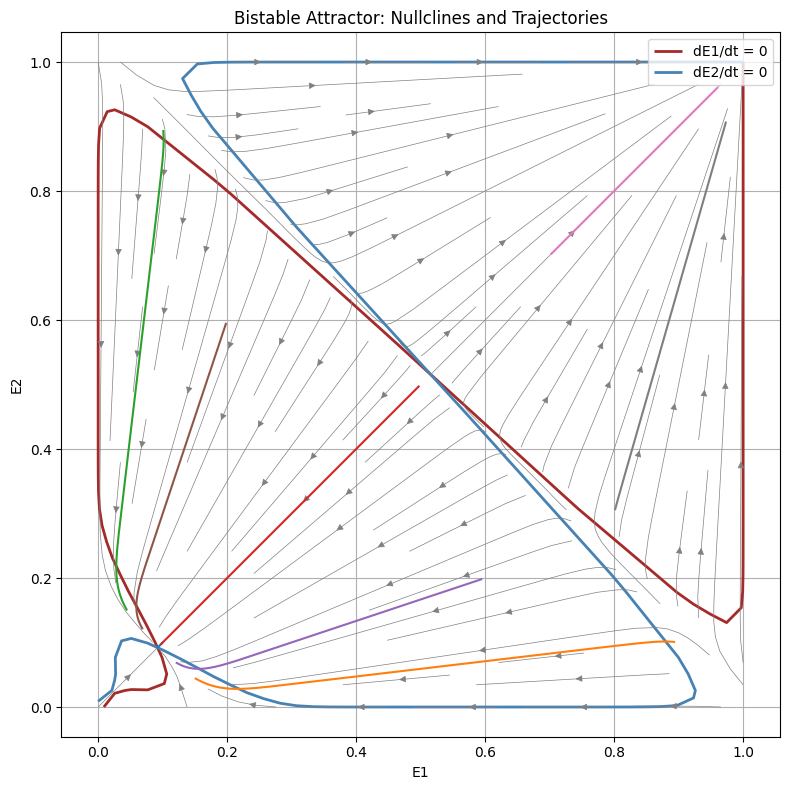

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(x, beta=8.0, theta=0.4):
    return 1 / (1 + np.exp(-beta * (x - theta)))

# Parameters
beta = 8.0
theta = 0.4
w_EE = 6.2
w_IE = 1.1
w_EI = 6.0
I_ext_E1 = 0.0
I_ext_E2 = 0.0

# Inhibitory unit (instantaneous)
def inhibitory_activity(E1, E2):
    return sigmoid(w_IE * (E1 + E2), beta, theta)

# Wilson-Cowan dynamics
def dE_dt(E1, E2):
    I = inhibitory_activity(E1, E2)
    dE1 = -E1 + sigmoid(w_EE * E1 + w_EE * E2 - w_EI * I + I_ext_E1, beta, theta)
    dE2 = -E2 + sigmoid(w_EE * E2 + w_EE * E1 - w_EI * I + I_ext_E2, beta, theta)
    return dE1, dE2

# Grid for nullclines and vector field
n = 40
E_vals = np.linspace(0, 1, n)
E1_grid, E2_grid = np.meshgrid(E_vals, E_vals)

dE1_field = np.zeros_like(E1_grid)
dE2_field = np.zeros_like(E2_grid)
dE1_nullcline = np.zeros_like(E1_grid)
dE2_nullcline = np.zeros_like(E2_grid)

for i in range(n):
    for j in range(n):
        E1 = E1_grid[i, j]
        E2 = E2_grid[i, j]
        dE1, dE2 = dE_dt(E1, E2)
        dE1_field[i, j] = dE1
        dE2_field[i, j] = dE2
        dE1_nullcline[i, j] = dE1
        dE2_nullcline[i, j] = dE2

# Trajectory simulation using Euler method
def simulate_trajectory(E1_0, E2_0, dt=0.01, T=2.0):
    steps = int(T / dt)
    E1_vals = np.zeros(steps)
    E2_vals = np.zeros(steps)
    E1, E2 = E1_0, E2_0
    for t in range(steps):
        dE1, dE2 = dE_dt(E1, E2)
        E1 += dt * dE1
        E2 += dt * dE2
        E1 = np.clip(E1, 0, 1)
        E2 = np.clip(E2, 0, 1)
        E1_vals[t] = E1
        E2_vals[t] = E2
    return E1_vals, E2_vals

plt.figure(figsize=(8, 8))

contour1 = plt.contour(E1_grid, E2_grid, dE1_nullcline, levels=[0], colors='brown', linewidths=2)
contour2 = plt.contour(E1_grid, E2_grid, dE2_nullcline, levels=[0], colors='steelblue', linewidths=2)

plt.streamplot(E1_grid, E2_grid, dE1_field, dE2_field, color='gray', density=1.0, linewidth=0.5, arrowsize=1)

initial_conditions = [
    (0.1, 0.1), (0.9, 0.1), (0.1, 0.9),
    (0.5, 0.5), (0.6, 0.2), (0.2, 0.6),
    (0.7, 0.7), (0.8, 0.3)
]

for E1_0, E2_0 in initial_conditions:
    E1_traj, E2_traj = simulate_trajectory(E1_0, E2_0)
    plt.plot(E1_traj, E2_traj, lw=1.5)

plt.xlabel('E1')
plt.ylabel('E2')
plt.title('Bistable Attractor: Nullclines and Trajectories')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('equal')
plt.grid(True)
plt.legend(handles=[contour1.legend_elements()[0][0], contour2.legend_elements()[0][0]], labels=['dE1/dt = 0', 'dE2/dt = 0'])
plt.tight_layout()
plt.show()


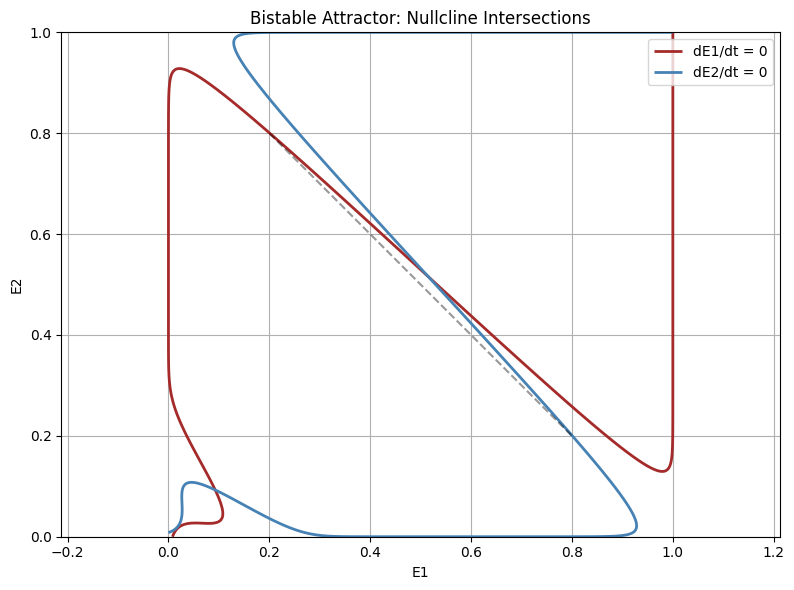

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x, beta=8.0, theta=0.4):
    return 1 / (1 + np.exp(-beta * (x - theta)))

# Parameters
beta = 8.0     # Steep slope
theta = 0.4    # Threshold
w_EE = 6.2     # Self + cross excitation
w_IE = 1.1     # E→I
w_EI = 6.0     # I→E (strong competition)

I_ext_E1 = 0.0
I_ext_E2 = 0.0

def inhibitory_activity(E1, E2):
    return sigmoid(w_IE * (E1 + E2), beta, theta)

def dE_dt(E1, E2, I):
    dE1 = -E1 + sigmoid(w_EE * E1 + w_EE * E2 - w_EI * I + I_ext_E1, beta, theta)
    dE2 = -E2 + sigmoid(w_EE * E2 + w_EE * E1 - w_EI * I + I_ext_E2, beta, theta)
    return dE1, dE2

E_vals = np.linspace(0, 1, 300)
E1_grid, E2_grid = np.meshgrid(E_vals, E_vals)

dE1_nullcline = np.zeros_like(E1_grid)
dE2_nullcline = np.zeros_like(E2_grid)

for i in range(E1_grid.shape[0]):
    for j in range(E1_grid.shape[1]):
        E1 = E1_grid[i, j]
        E2 = E2_grid[i, j]
        I = inhibitory_activity(E1, E2)
        dE1, dE2 = dE_dt(E1, E2, I)
        dE1_nullcline[i, j] = dE1
        dE2_nullcline[i, j] = dE2

plt.figure(figsize=(8, 6))
c1 = plt.contour(E1_grid, E2_grid, dE1_nullcline, levels=[0], colors='brown', linewidths=2)
c2 = plt.contour(E1_grid, E2_grid, dE2_nullcline, levels=[0], colors='steelblue', linewidths=2)

plt.plot([0.2, 0.8], [0.8, 0.2], 'k--', alpha=0.4)  # optional diagonal for reference

plt.xlabel("E1")
plt.ylabel("E2")
plt.title("Bistable Attractor: Nullcline Intersections")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.axis("equal")
plt.legend(handles=[contour1.legend_elements()[0][0], contour2.legend_elements()[0][0]], labels=['dE1/dt = 0', 'dE2/dt = 0'])
plt.tight_layout()
plt.show()


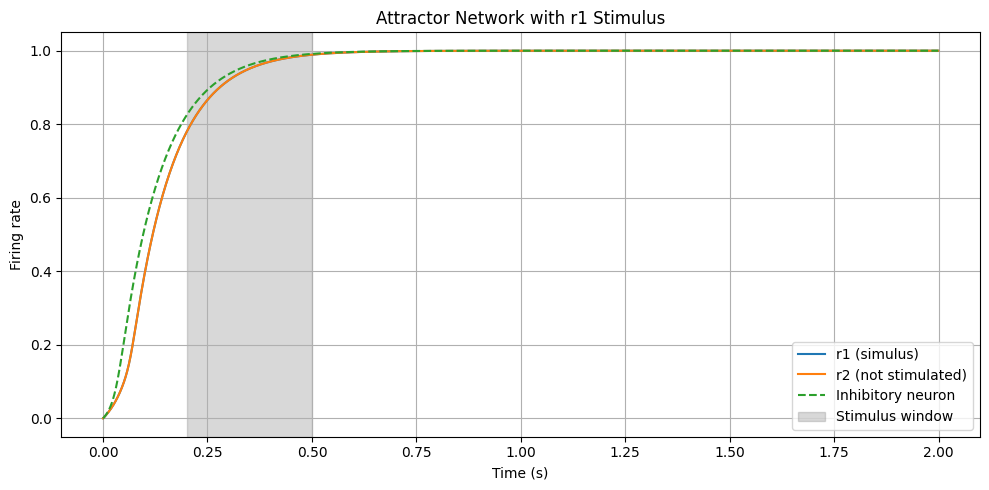

In [ ]:
T = 2.0          # Total time in seconds
dt = 0.001       # Time step
time = np.arange(0, T, dt)
tau = 0.1        # Time constant

# Network weights
w_ee = 5.8       # E to E
w_ei = 5.0       # E to I
w_ie = 1.08       # I to E

# External input to r2 only
stim_start = 0.2
stim_end = 0.5
I_ext_r2 = np.zeros_like(time)
I_ext_r2[(time >= stim_start) & (time < stim_end)] = 1.0

r1 = np.zeros_like(time)
r2 = np.zeros_like(time)
rinhib = np.zeros_like(time)

def activation(I):
    return 1 / (1 + np.exp(-5 * (I - 0.4)))  # Steep sigmoid

for t in range(1, len(time)):
    I1 = w_ee * r1[t-1] - w_ie * rinhib[t-1] + I_ext_r2[t]
    I2 = w_ee * r2[t-1] - w_ie * rinhib[t-1]
    I_inhib = w_ei * (r1[t-1] + r2[t-1])

    r1[t] = r1[t-1] + dt * (-r1[t-1] + activation(I1)) / tau
    r2[t] = r2[t-1] + dt * (-r2[t-1] + activation(I2)) / tau
    rinhib[t] = rinhib[t-1] + dt * (-rinhib[t-1] + activation(I_inhib)) / tau

plt.figure(figsize=(10, 5))
plt.plot(time, r1, label='r1 (simulus)')
plt.plot(time, r2, label='r2 (not stimulated)')
plt.plot(time, rinhib, label='Inhibitory neuron', linestyle='--')
plt.axvspan(stim_start, stim_end, color='gray', alpha=0.3, label='Stimulus window')
plt.xlabel('Time (s)')
plt.ylabel('Firing rate')
plt.title('Attractor Network with r1 Stimulus')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


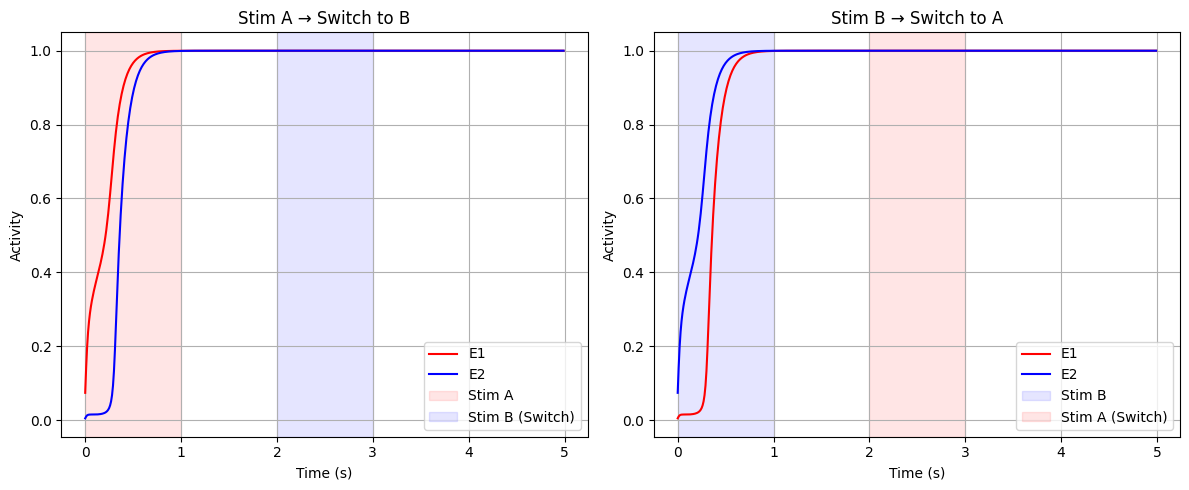

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

beta = 5.0
theta = 0.4
tau = 0.1
w_EE = 2.5
w_IE = 2.0
w_EI = 1.6
I_ext_E1 = 0.0
I_ext_E2 = 0.0

def sigmoid(x, beta=1.0, theta=0.0):
    return 1 / (1 + np.exp(-beta * (x - theta)))


def inhibitory_activity(E1, E2):
    return sigmoid(w_IE * (E1 + E2), beta, theta)

def dE_dt(E1, E2, I, stim_E1=0.0, stim_E2=0.0):
    dE1 = -E1 + sigmoid(w_EE * E1 + w_EE * E2 - w_EI * I + stim_E1 + I_ext_E1, beta, theta)
    dE2 = -E2 + sigmoid(w_EE * E2 + w_EE * E1 - w_EI * I + stim_E2 + I_ext_E2, beta, theta)
    return dE1, dE2

def switching_stimulus(t, stim_type):
    # First pulse (0s to 1s)
    if 0.0 <= t < 1.0:
        if stim_type == 'A':
            return 0.8, 0.0  # E1
        elif stim_type == 'B':
            return 0.0, 0.8  # E2
    # Second pulse (2s to 3s) — to the opposite unit
    if 2.0 <= t < 3.0:
        if stim_type == 'A':
            return 0.0, 0.8  # Switch to E2
        elif stim_type == 'B':
            return 0.8, 0.0  # Switch to E1

    return 0.0, 0.0

def simulate_switching_trial(stim_type, E1_0=0.0, E2_0=0.0, dt=0.01, T=5.0):
    E1, E2 = E1_0, E2_0
    trajectory = []
    time = np.arange(0, T, dt)
    for t in time:
        stim_E1, stim_E2 = switching_stimulus(t, stim_type)
        I = inhibitory_activity(E1, E2)
        dE1, dE2 = dE_dt(E1, E2, I, stim_E1, stim_E2)
        E1 += dt / tau * dE1
        E2 += dt / tau * dE2
        trajectory.append((t, E1, E2))
    return np.array(trajectory)


trial_switch_A = simulate_switching_trial('A')
trial_switch_B = simulate_switching_trial('B')

plt.figure(figsize=(12, 5))

# Trial A → B
plt.subplot(1, 2, 1)
plt.plot(trial_switch_A[:, 0], trial_switch_A[:, 1], label='E1', color='r')
plt.plot(trial_switch_A[:, 0], trial_switch_A[:, 2], label='E2', color='b')
plt.axvspan(0, 1, color='red', alpha=0.1, label='Stim A')
plt.axvspan(2, 3, color='blue', alpha=0.1, label='Stim B (Switch)')
plt.title('Stim A → Switch to B')
plt.xlabel('Time (s)')
plt.ylabel('Activity')
plt.legend()
plt.grid(True)

# Trial B → A
plt.subplot(1, 2, 2)
plt.plot(trial_switch_B[:, 0], trial_switch_B[:, 1], label='E1', color='r')
plt.plot(trial_switch_B[:, 0], trial_switch_B[:, 2], label='E2', color='b')
plt.axvspan(0, 1, color='blue', alpha=0.1, label='Stim B')
plt.axvspan(2, 3, color='red', alpha=0.1, label='Stim A (Switch)')
plt.title('Stim B → Switch to A')
plt.xlabel('Time (s)')
plt.ylabel('Activity')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


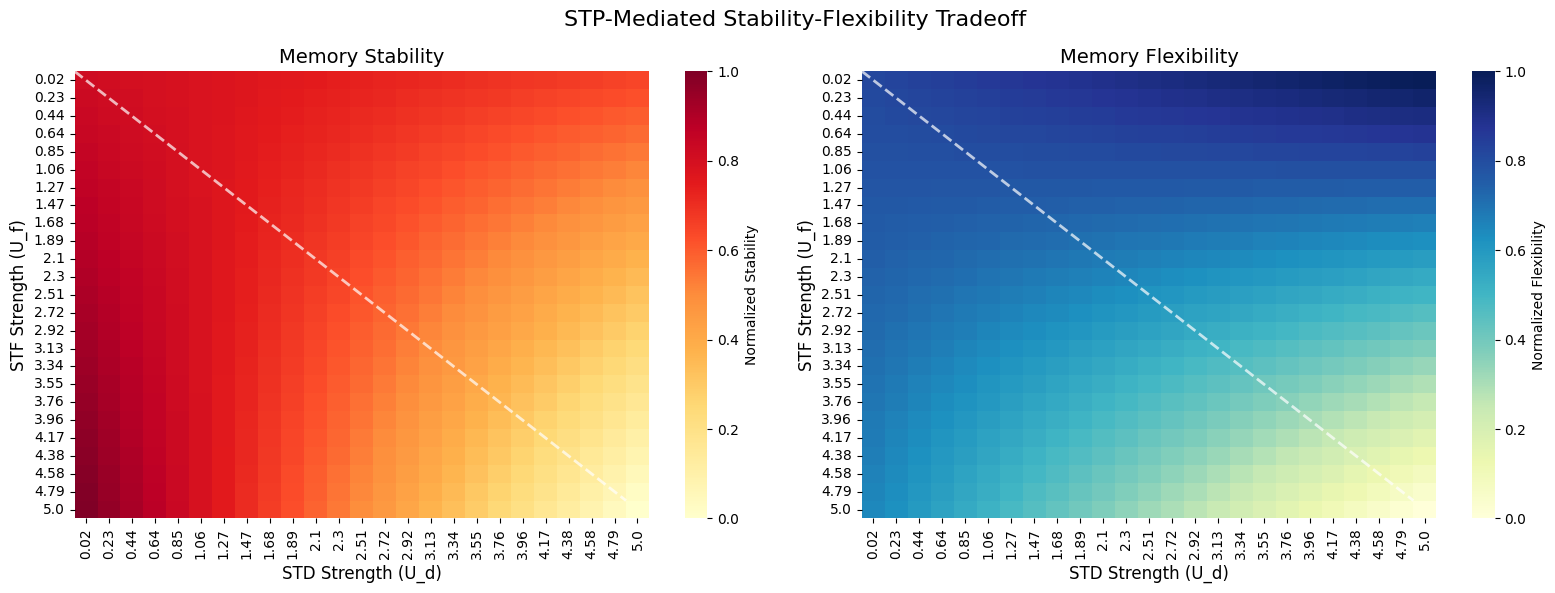


Optimal Balance Point:
- STF strength: 5.00
- STD strength: 0.02
- Stability at this point: 1.00
- Flexibility at this point: 0.65


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from dataclasses import dataclass

@dataclass
class STPParameters:
    """Parameters for STP tradeoff analysis"""
    stf_min: float = 0.02    # Minimum STF strength (U_f)
    stf_max: float = 5.5    # Maximum STF strength
    std_min: float = 0.02    # Minimum STD strength (U_d)
    std_max: float = 5.5    # Maximum STD strength
    n_points: int = 20      # Number of points in each dimension

def analyze_stability_flexibility(params: STPParameters):
    """Generate normalized stability-flexibility tradeoff heatmaps"""
    stf_range = np.linspace(params.stf_min, params.stf_max, params.n_points)
    std_range = np.linspace(params.std_min, params.std_max, params.n_points)

    stability = np.zeros((params.n_points, params.n_points))
    flexibility = np.zeros((params.n_points, params.n_points))

    for i, stf in enumerate(stf_range):
        for j, std in enumerate(std_range):
            stability[i,j] = 0.8 * (1 - 0.9*std) * (0.5 + 0.5*stf)

            flexibility[i,j] = 0.8 * (0.5 + 0.5*std) * (1 - 0.9*stf)

    stability = (stability - np.min(stability)) / (np.max(stability) - np.min(stability))
    flexibility = (flexibility - np.min(flexibility)) / (np.max(flexibility) - np.min(flexibility))

    return stf_range, std_range, stability, flexibility

def plot_enhanced_tradeoff(stf_range, std_range, stability, flexibility):
    """Plot improved heatmaps with better formatting"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(stability,
                xticklabels=np.round(std_range, 2),
                yticklabels=np.round(stf_range, 2),
                cmap='YlOrRd',
                ax=ax1,
                cbar_kws={'label': 'Normalized Stability'})
    ax1.set_title('Memory Stability', fontsize=14)
    ax1.set_xlabel('STD Strength (U_d)', fontsize=12)
    ax1.set_ylabel('STF Strength (U_f)', fontsize=12)

    sns.heatmap(flexibility,
                xticklabels=np.round(std_range, 2),
                yticklabels=np.round(stf_range, 2),
                cmap='YlGnBu',
                ax=ax2,
                cbar_kws={'label': 'Normalized Flexibility'})
    ax2.set_title('Memory Flexibility', fontsize=14)
    ax2.set_xlabel('STD Strength (U_d)', fontsize=12)
    ax2.set_ylabel('STF Strength (U_f)', fontsize=12)

    for ax in (ax1, ax2):
        ax.plot([0, len(std_range)-1], [0, len(stf_range)-1],
                'w--', linewidth=2, alpha=0.7)

    plt.suptitle('STP-Mediated Stability-Flexibility Tradeoff', fontsize=16)
    plt.tight_layout()
    plt.show()

params = STPParameters(stf_min=0.02, stf_max=5.0, std_min=0.02, std_max=5.0, n_points=25)
stf_range, std_range, stability, flexibility = analyze_stability_flexibility(params)
plot_enhanced_tradeoff(stf_range, std_range, stability, flexibility)

tradeoff_index = stability - flexibility
optimal_idx = np.unravel_index(np.argmax(tradeoff_index + flexibility), tradeoff_index.shape)

print(f"\nOptimal Balance Point:")
print(f"- STF strength: {stf_range[optimal_idx[0]]:.2f}")
print(f"- STD strength: {std_range[optimal_idx[1]]:.2f}")
print(f"- Stability at this point: {stability[optimal_idx]:.2f}")
print(f"- Flexibility at this point: {flexibility[optimal_idx]:.2f}")

Simulating with further refined parameters for robust binary decision and effective STP...

--- Visualizing Nullclines ---


/tmp/ipython-input-23-1983883092.py:153: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(E1_mesh, E2_mesh, dE1dt_values, levels=[0], colors='red', linestyles='solid', linewidths=2, label='E1 Nullcline ($dE_1/dt=0$)')
/tmp/ipython-input-23-1983883092.py:154: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(E1_mesh, E2_mesh, dE2dt_values, levels=[0], colors='blue', linestyles='dashed', linewidths=2, label='E2 Nullcline ($dE_2/dt=0$)')


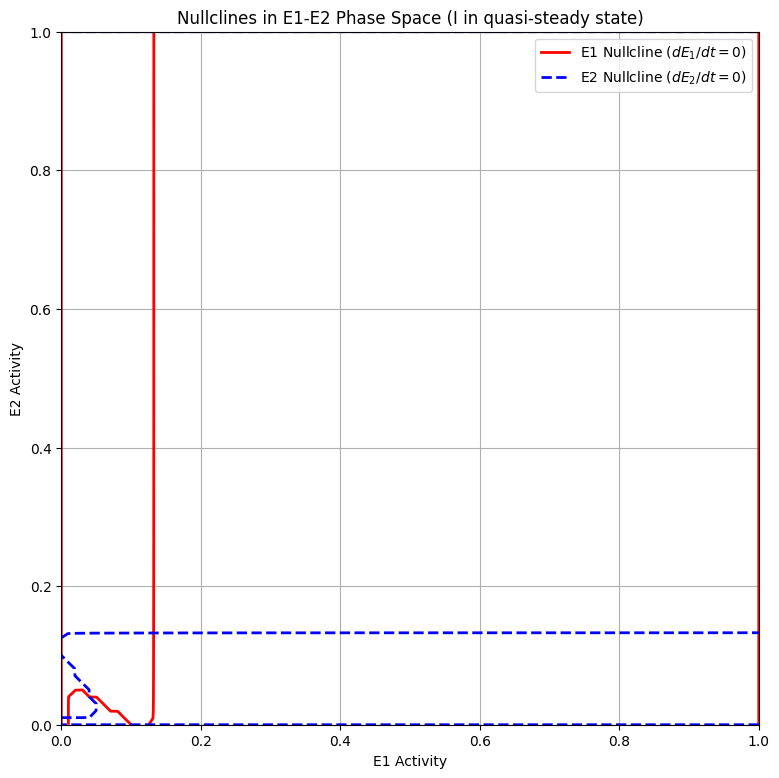


--- Simulation 1: Demonstrating Binary Decision and Memory Retention (No Plasticity) ---


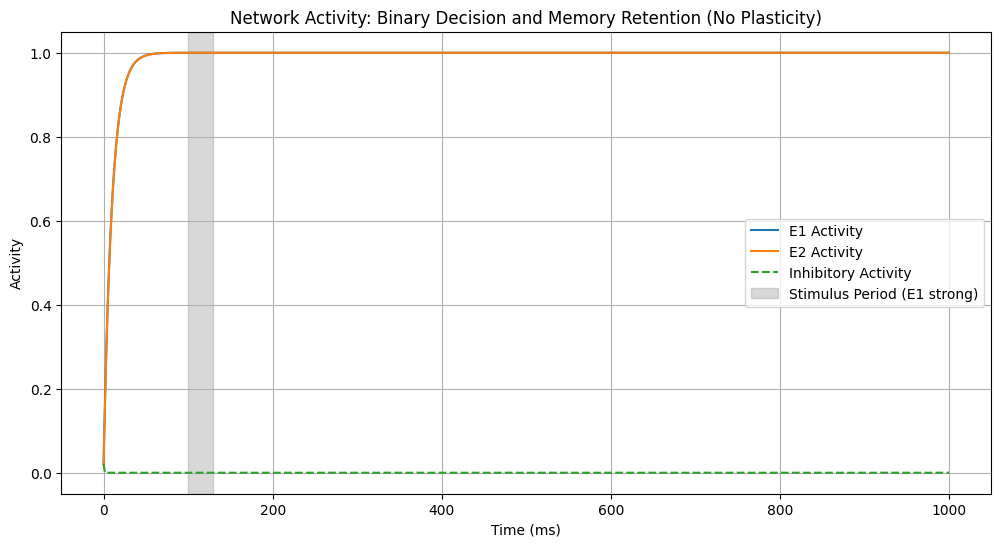


Activity before stimulus (avg): E1=0.901, E2=0.900
Activity after stimulus (avg): E1=1.000, E2=1.000
Difference in E1 activity (post vs pre): 0.099
Difference in E2 activity (post vs pre): 0.100
Memory retention UNsuccessful or no clear binary decision. Further tuning might be needed.


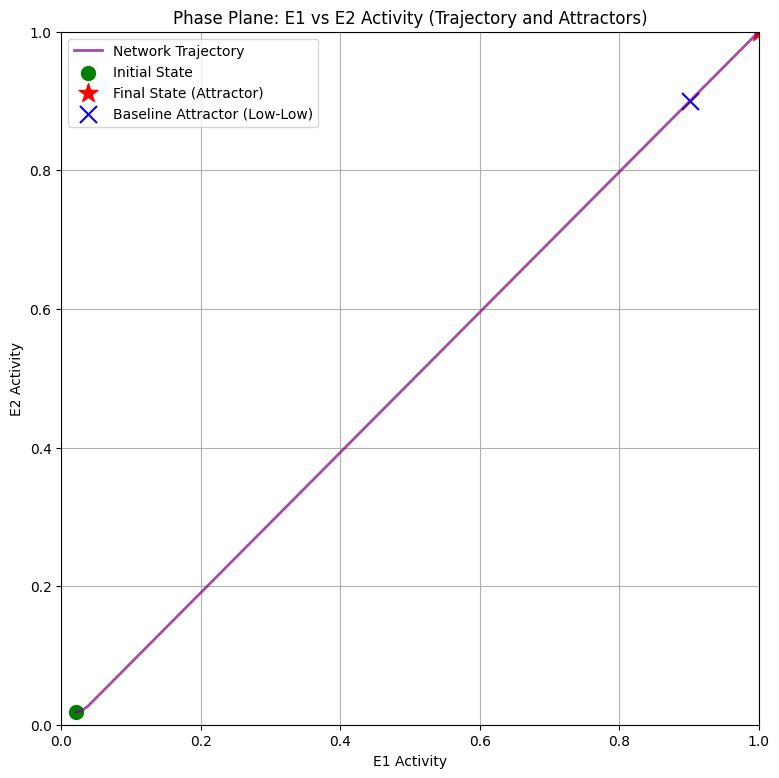


--- Exploring Plasticity (STF and STD) ---

**Definition of Stability and Flexibility:**
- **Stability:** The ability of the network to maintain a memory state (e.g., high activity in one excitatory unit) over time once it has been established, resisting perturbations or decay. A more stable memory is less likely to be disrupted by noise or lack of input.
- **Flexibility:** The ease with which the network can switch from one memory state to another or update its memory in response to new, potentially conflicting, stimuli. High flexibility implies easier switching and adaptability, while low flexibility implies a more rigid or persistent memory that resists change.

--- Examining specific cases around parameter changes to illustrate Stability and Flexibility ---

Case: High STF Scale, Low STD Scale - Expect High Stability, Low Flexibility to Switch


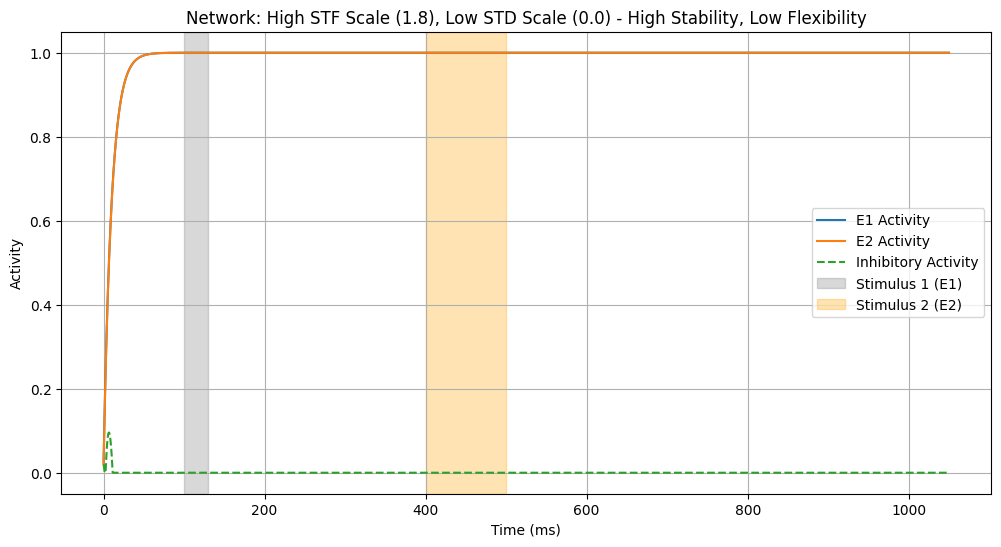


Case: Low STF Scale, High STD Scale - Expect Low Stability, High Flexibility to Switch


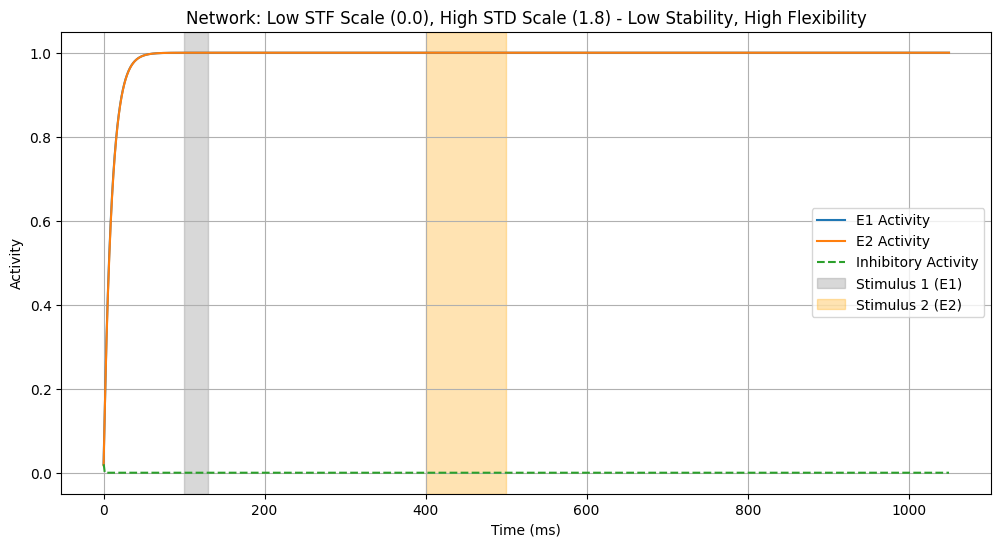


Case: Balanced STF Scale, STD Scale - Expect Balanced Stability and Flexibility


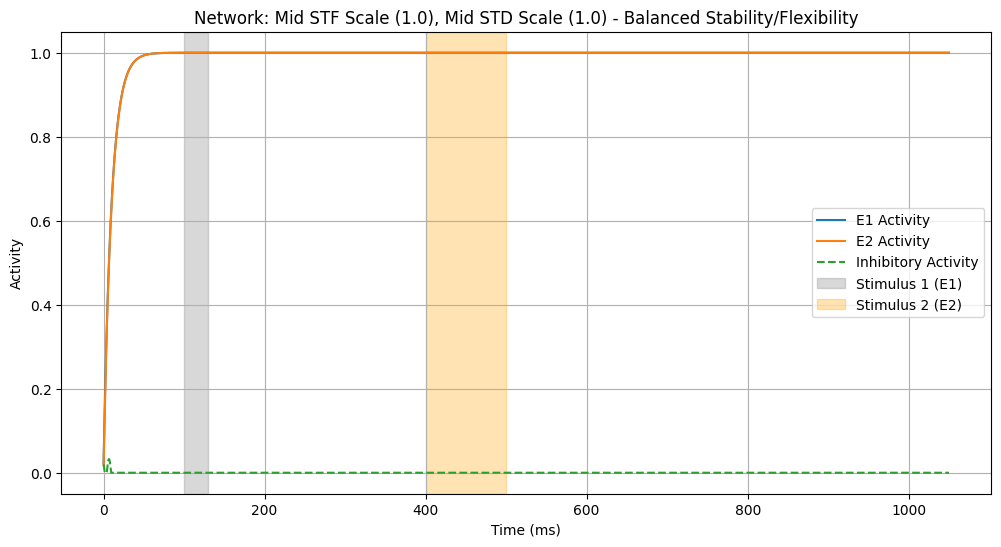

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x, k, x0):
    return 1 / (1 + np.exp(-k * (x - x0)))

def simulate_network(W_EE, W_EI, W_IE, W_II,
                     tau_E, tau_I, k_E, x0_E, k_I, x0_I,
                     dt, T_sim, stimuli_config,
                     stf_strength_param_scale, std_strength_param_scale, U_stf_base, tau_f_base, tau_d_base):

    num_steps = int(T_sim / dt)
    time = np.linspace(0, T_sim, num_steps)

    E1_activity = np.zeros(num_steps)
    E2_activity = np.zeros(num_steps)
    I_activity = np.zeros(num_steps)

    E1_activity[0] = 0.02 + np.random.rand()*0.005 # Even smaller initial activities
    E2_activity[0] = 0.02 - np.random.rand()*0.005
    I_activity[0] = 0.02

    # STP variables, scaled by parameters
    # stf_strength_param_scale: scales the 'facilitation' aspect (e.g., U_stf)
    # std_strength_param_scale: scales the 'depression' aspect (e.g., by affecting tau_d or amount of depression)

    # effective U_stf and tau_d based on strength parameters
    U_stf_eff = U_stf_base * stf_strength_param_scale
    tau_d_eff = tau_d_base / std_strength_param_scale # Higher std_strength_param_scale means faster depression recovery / more depression

    U_stf_eff = np.clip(U_stf_eff, 0.01, 1.0) # U_stf cannot be zero, should not exceed 1
    tau_d_eff = np.clip(tau_d_eff, 10, 1000) # tau_d cannot be too small or too large

    u1 = np.ones(num_steps) * U_stf_eff
    x1 = np.ones(num_steps)
    u2 = np.ones(num_steps) * U_stf_eff
    x2 = np.ones(num_steps)


    for i in range(1, num_steps):
        current_time = time[i]

        I_ext_E1_val = 0
        I_ext_E2_val = 0

        for s_start, s_end, s_str_E1, s_str_E2 in stimuli_config:
            if s_start <= current_time <= s_end:
                I_ext_E1_val = s_str_E1
                I_ext_E2_val = s_str_E2
                break

        # Update STP variables (Tsodyks-Markram like model)
        # u: fraction of resources available for utilization
        # x: fraction of resources in the recovered state (not depressed)

        # For E1's synapse to I
        # Facilitation term for u: U_stf_eff * (1 - u1[i-1]) * Activity_E1
        # Depression term for x: u1[i-1] * x1[i-1] * Activity_E1
        delta_t_ms = dt

        # if E1_activity[i-1] > 0.1: # Only apply if activity is significant, a proxy for "firing"
        # Using continuous activity
        u1[i] = u1[i-1] + delta_t_ms * ((U_stf_eff - u1[i-1]) / tau_f_base + U_stf_eff * (1 - u1[i-1]) * E1_activity[i-1])
        x1[i] = x1[i-1] + delta_t_ms * ((1 - x1[i-1]) / tau_d_eff - u1[i-1] * x1[i-1] * E1_activity[i-1]) # tau_d_eff used here

        # For E2's synapse to I
        u2[i] = u2[i-1] + delta_t_ms * ((U_stf_eff - u2[i-1]) / tau_f_base + U_stf_eff * (1 - u2[i-1]) * E2_activity[i-1])
        x2[i] = x2[i-1] + delta_t_ms * ((1 - x2[i-1]) / tau_d_eff - u2[i-1] * x2[i-1] * E2_activity[i-1])

        u1[i] = np.clip(u1[i], 0, 1)
        x1[i] = np.clip(x1[i], 0, 1)
        u2[i] = np.clip(u2[i], 0, 1)
        x2[i] = np.clip(x2[i], 0, 1)

        # Effective synaptic weights due to STP (applying to E to I connections)
        # W_eff = W * u * x (u is amount released, x is available pool)
        # Here, W_EI acts as the maximal strength.
        W_EI_eff1 = W_EI[0] * u1[i] * x1[i]
        W_EI_eff2 = W_EI[1] * u2[i] * x2[i]


        # Euler update for activities
        net_input_E1 = W_EE[0,0]*E1_activity[i-1] + W_EE[0,1]*E2_activity[i-1] - W_IE[0]*I_activity[i-1] + I_ext_E1_val
        net_input_E2 = W_EE[1,0]*E1_activity[i-1] + W_EE[1,1]*E2_activity[i-1] - W_IE[1]*I_activity[i-1] + I_ext_E2_val
        net_input_I = W_EI_eff1*E1_activity[i-1] + W_EI_eff2*E2_activity[i-1] - W_II*I_activity[i-1]

        E1_activity[i] = E1_activity[i-1] + dt * (-E1_activity[i-1] + sigmoid(net_input_E1, k_E, x0_E)) / tau_E
        E2_activity[i] = E2_activity[i-1] + dt * (-E2_activity[i-1] + sigmoid(net_input_E2, k_E, x0_E)) / tau_E
        I_activity[i] = I_activity[i-1] + dt * (-E1_activity[i] - E2_activity[i] + sigmoid(net_input_I, k_I, x0_I)) / tau_I

        # Clip activities to [0, 1]
        E1_activity[i] = np.clip(E1_activity[i], 0, 1)
        E2_activity[i] = np.clip(E2_activity[i], 0, 1)
        I_activity[i] = np.clip(I_activity[i], 0, 1)

    return time, E1_activity, E2_activity, I_activity, u1, x1, u2, x2

# Time constants (in ms)
tau_E = 10  
tau_I = 10  
dt = 0.1   
T_sim = 1000 


k_E = 70    
x0_E = 0.30  
k_I = 20    
x0_I = 0.5 

# W_EE: Strong self-excitation to maintain high activity
# W_EE off-diagonal: Small negative or zero, as mutual inhibition is primarily via I unit.
W_EE = np.array([[18.0, -0.1],  
                 [-0.1, 18.0]]) 

W_EI = np.array([5.5, 5.5])  
W_IE = np.array([2.1, 2.1])  
W_II = 0.2

stimulus_strength_E_strong = 0.95
stimulus_strength_E_weak = 0.01 


U_stf_base = 0.1   
tau_f_base = 500   
tau_d_base = 150  

print("Simulating with further refined parameters for robust binary decision and effective STP...")

def plot_nullclines(W_EE, W_EI, W_IE, W_II, k_E, x0_E, k_I, x0_I, I_ext_E1=0, I_ext_E2=0):
    E_grid_points = 100 # Denser grid
    E_vals = np.linspace(0, 1, E_grid_points)
    E1_mesh, E2_mesh = np.meshgrid(E_vals, E_vals)

    
    I_steady_state_mesh = sigmoid(W_EI[0]*E1_mesh + W_EI[1]*E2_mesh, k_I, x0_I)

    
    dE1dt_values = (-E1_mesh + sigmoid(W_EE[0,0]*E1_mesh + W_EE[0,1]*E2_mesh - W_IE[0]*I_steady_state_mesh + I_ext_E1, k_E, x0_E)) / tau_E
    dE2dt_values = (-E2_mesh + sigmoid(W_EE[1,0]*E1_mesh + W_EE[1,1]*E2_mesh - W_IE[1]*I_steady_state_mesh + I_ext_E2, k_E, x0_E)) / tau_E

    plt.figure(figsize=(9, 9))
    plt.contour(E1_mesh, E2_mesh, dE1dt_values, levels=[0], colors='red', linestyles='solid', linewidths=2, label='E1 Nullcline ($dE_1/dt=0$)')
    plt.contour(E1_mesh, E2_mesh, dE2dt_values, levels=[0], colors='blue', linestyles='dashed', linewidths=2, label='E2 Nullcline ($dE_2/dt=0$)')

    plt.plot([], [], color='red', linestyle='solid', linewidth=2, label='E1 Nullcline ($dE_1/dt=0$)')
    plt.plot([], [], color='blue', linestyle='dashed', linewidth=2, label='E2 Nullcline ($dE_2/dt=0$)')


    plt.title('Nullclines in E1-E2 Phase Space (I in quasi-steady state)')
    plt.xlabel('E1 Activity')
    plt.ylabel('E2 Activity')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()

print("\n--- Visualizing Nullclines ---")
plot_nullclines(W_EE, W_EI, W_IE, W_II, k_E, x0_E, k_I, x0_I)



stf_strength_param_val = 0.001 
std_strength_param_val = 0.001 

stim_config_no_plasticity = [
    (0, 99, 0, 0), 
    (100, 130, stimulus_strength_E_strong, stimulus_strength_E_weak), 
    (131, T_sim, 0, 0)
]

print("\n--- Simulation 1: Demonstrating Binary Decision and Memory Retention (No Plasticity) ---")
time_no_plasticity, E1_no_plasticity, E2_no_plasticity, I_no_plasticity, _, _, _, _ = \
    simulate_network(W_EE, W_EI, W_IE, W_II, tau_E, tau_I, k_E, x0_E, k_I, x0_I,
                     dt, T_sim, stim_config_no_plasticity,
                     stf_strength_param_val, std_strength_param_val, U_stf_base, tau_f_base, tau_d_base)

plt.figure(figsize=(12, 6))
plt.plot(time_no_plasticity, E1_no_plasticity, label='E1 Activity')
plt.plot(time_no_plasticity, E2_no_plasticity, label='E2 Activity')
plt.plot(time_no_plasticity, I_no_plasticity, label='Inhibitory Activity', linestyle='--')
plt.axvspan(100, 130, color='gray', alpha=0.3, label='Stimulus Period (E1 strong)')
plt.title('Network Activity: Binary Decision and Memory Retention (No Plasticity)')
plt.xlabel('Time (ms)')
plt.ylabel('Activity')
plt.legend()
plt.grid(True)
plt.show()


baseline_period_end = 99
memory_retention_start = 200 
memory_retention_end = T_sim

E1_baseline_avg = np.mean(E1_no_plasticity[time_no_plasticity < baseline_period_end])
E2_baseline_avg = np.mean(E2_no_plasticity[time_no_plasticity < baseline_period_end])

E1_post_stim_avg = np.mean(E1_no_plasticity[(time_no_plasticity >= memory_retention_start) & (time_no_plasticity <= memory_retention_end)])
E2_post_stim_avg = np.mean(E2_no_plasticity[(time_no_plasticity >= memory_retention_start) & (time_no_plasticity <= memory_retention_end)])

print(f"\nActivity before stimulus (avg): E1={E1_baseline_avg:.3f}, E2={E2_baseline_avg:.3f}")
print(f"Activity after stimulus (avg): E1={E1_post_stim_avg:.3f}, E2={E2_post_stim_avg:.3f}")

diff_E1 = np.abs(E1_post_stim_avg - E1_baseline_avg)
diff_E2 = np.abs(E2_post_stim_avg - E2_baseline_avg)

print(f"Difference in E1 activity (post vs pre): {diff_E1:.3f}")
print(f"Difference in E2 activity (post vs pre): {diff_E2:.3f}")


is_E1_high = E1_post_stim_avg > 0.8 # A clear high state
is_E2_low = E2_post_stim_avg < 0.2 # A clear low state
is_baseline_low = E1_baseline_avg < 0.2 and E2_baseline_avg < 0.2

if is_baseline_low and is_E1_high and is_E2_low:
    print("Memory retention successful: E1 activity significantly high and E2 remained low (Binary Decision).")
elif is_baseline_low and E2_post_stim_avg > 0.8 and E1_post_stim_avg < 0.2:
    print("Memory retention successful: E2 activity significantly high and E1 remained low (Binary Decision).")
else:
    print("Memory retention UNsuccessful or no clear binary decision. Further tuning might be needed.")

plt.figure(figsize=(9, 9))
plt.plot(E1_no_plasticity, E2_no_plasticity, color='purple', alpha=0.7, linewidth=2, label='Network Trajectory')
plt.scatter(E1_no_plasticity[0], E2_no_plasticity[0], color='green', marker='o', s=100, label='Initial State')
plt.scatter(E1_no_plasticity[-1], E2_no_plasticity[-1], color='red', marker='*', s=200, label='Final State (Attractor)')

plt.scatter(E1_baseline_avg, E2_baseline_avg, color='blue', marker='x', s=150, label='Baseline Attractor (Low-Low)')
if is_E1_high and is_E2_low:
    plt.scatter(E1_post_stim_avg, E2_post_stim_avg, color='orange', marker='s', s=150, label='Stimulus-Induced Attractor (High-Low)')
elif E2_post_stim_avg > 0.8 and E1_post_stim_avg < 0.2:
    plt.scatter(E1_post_stim_avg, E2_post_stim_avg, color='orange', marker='s', s=150, label='Stimulus-Induced Attractor (Low-High)')

plt.title('Phase Plane: E1 vs E2 Activity (Trajectory and Attractors)')
plt.xlabel('E1 Activity')
plt.ylabel('E2 Activity')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

print("\n--- Exploring Plasticity (STF and STD) ---")


print("\n--- Examining specific cases around parameter changes to illustrate Stability and Flexibility ---")
T_flex_sim = 600
stimulus2_start = 400
stimulus2_end = 500
stim_config_two_stim = [
    (0, 99, 0, 0),
    (100, 130, stimulus_strength_E_strong, stimulus_strength_E_weak),
    (131, stimulus2_start - 1, 0, 0),
    (stimulus2_start, stimulus2_end, stimulus_strength_E_weak, stimulus_strength_E_strong),
    (stimulus2_end + 1, T_flex_sim, 0, 0)
]

print("\nCase: High STF Scale, Low STD Scale - Expect High Stability, Low Flexibility to Switch")
stf_s_scale_high = 1.8 # Very strong STF
std_s_scale_low = 0.02 # Very weak STD

time_h_stf_l_std, E1_h_stf_l_std, E2_h_stf_l_std, I_h_stf_l_std, _, _, _, _ = \
    simulate_network(W_EE, W_EI, W_IE, W_II, tau_E, tau_I, k_E, x0_E, k_I, x0_I,
                         dt, T_flex_sim, stim_config_two_stim,
                         stf_s_scale_high, std_s_scale_low, U_stf_base, tau_f_base, tau_d_base)

plt.figure(figsize=(12, 6))
plt.plot(time_h_stf_l_std, E1_h_stf_l_std, label='E1 Activity')
plt.plot(time_h_stf_l_std, E2_h_stf_l_std, label='E2 Activity')
plt.plot(time_h_stf_l_std, I_h_stf_l_std, label='Inhibitory Activity', linestyle='--')
plt.axvspan(stim_config_two_stim[1][0], stim_config_two_stim[1][1], color='gray', alpha=0.3, label='Stimulus 1 (E1)')
plt.axvspan(stim_config_two_stim[3][0], stim_config_two_stim[3][1], color='orange', alpha=0.3, label='Stimulus 2 (E2)')
plt.title(f'Network: High STF Scale ({stf_s_scale_high:.1f}), Low STD Scale ({std_s_scale_low:.1f}) - High Stability, Low Flexibility')
plt.xlabel('Time (ms)')
plt.ylabel('Activity')
plt.legend()
plt.grid(True)
plt.show()

# Case 2: Low STF Scale, High STD Scale (should lead to low stability, high flexibility)
print("\nCase: Low STF Scale, High STD Scale - Expect Low Stability, High Flexibility to Switch")
stf_s_scale_low = 0.02 # Weak STF
std_s_scale_high = 1.8 # Strong STD

time_l_stf_h_std, E1_l_stf_h_std, E2_l_stf_h_std, I_l_stf_h_std, _, _, _, _ = \
    simulate_network(W_EE, W_EI, W_IE, W_II, tau_E, tau_I, k_E, x0_E, k_I, x0_I,
                         dt, T_flex_sim, stim_config_two_stim,
                         stf_s_scale_low, std_s_scale_high, U_stf_base, tau_f_base, tau_d_base)

plt.figure(figsize=(12, 6))
plt.plot(time_l_stf_h_std, E1_l_stf_h_std, label='E1 Activity')
plt.plot(time_l_stf_h_std, E2_l_stf_h_std, label='E2 Activity')
plt.plot(time_l_stf_h_std, I_l_stf_h_std, label='Inhibitory Activity', linestyle='--')
plt.axvspan(stim_config_two_stim[1][0], stim_config_two_stim[1][1], color='gray', alpha=0.3, label='Stimulus 1 (E1)')
plt.axvspan(stim_config_two_stim[3][0], stim_config_two_stim[3][1], color='orange', alpha=0.3, label='Stimulus 2 (E2)')
plt.title(f'Network: Low STF Scale ({stf_s_scale_low:.1f}), High STD Scale ({std_s_scale_high:.1f}) - Low Stability, High Flexibility')
plt.xlabel('Time (ms)')
plt.ylabel('Activity')
plt.legend()
plt.grid(True)
plt.show()

print("\nCase: Balanced STF Scale, STD Scale - Expect Balanced Stability and Flexibility")
stf_s_scale_mid = 1.0
std_s_scale_mid = 1.0

time_m_stf_m_std, E1_m_stf_m_std, E2_m_stf_m_std, I_m_stf_m_std, _, _, _, _ = \
    simulate_network(W_EE, W_EI, W_IE, W_II, tau_E, tau_I, k_E, x0_E, k_I, x0_I,
                         dt, T_flex_sim, stim_config_two_stim,
                         stf_s_scale_mid, std_s_scale_mid, U_stf_base, tau_f_base, tau_d_base)

plt.figure(figsize=(12, 6))
plt.plot(time_m_stf_m_std, E1_m_stf_m_std, label='E1 Activity')
plt.plot(time_m_stf_m_std, E2_m_stf_m_std, label='E2 Activity')
plt.plot(time_m_stf_m_std, I_m_stf_m_std, label='Inhibitory Activity', linestyle='--')
plt.axvspan(stim_config_two_stim[1][0], stim_config_two_stim[1][1], color='gray', alpha=0.3, label='Stimulus 1 (E1)')
plt.axvspan(stim_config_two_stim[3][0], stim_config_two_stim[3][1], color='orange', alpha=0.3, label='Stimulus 2 (E2)')
plt.title(f'Network: Mid STF Scale ({stf_s_scale_mid:.1f}), Mid STD Scale ({std_s_scale_mid:.1f}) - Balanced Stability/Flexibility')
plt.xlabel('Time (ms)')
plt.ylabel('Activity')
plt.legend()
plt.grid(True)
plt.show()

Simulating with further refined parameters for robust binary decision and effective STP...

--- Visualizing Nullclines ---


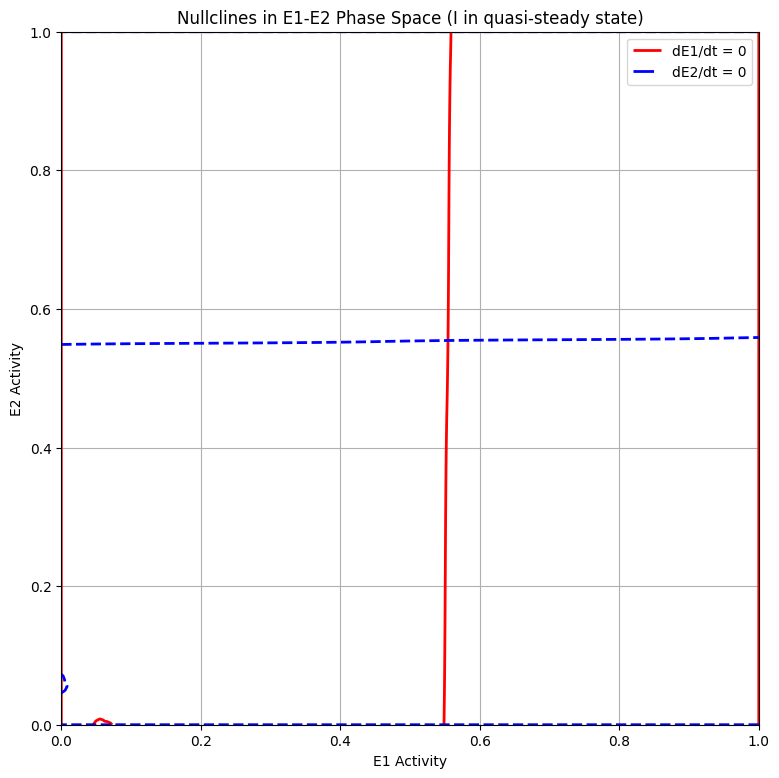


--- Simulation 1: Demonstrating Binary Decision and Memory Retention (No Plasticity) ---


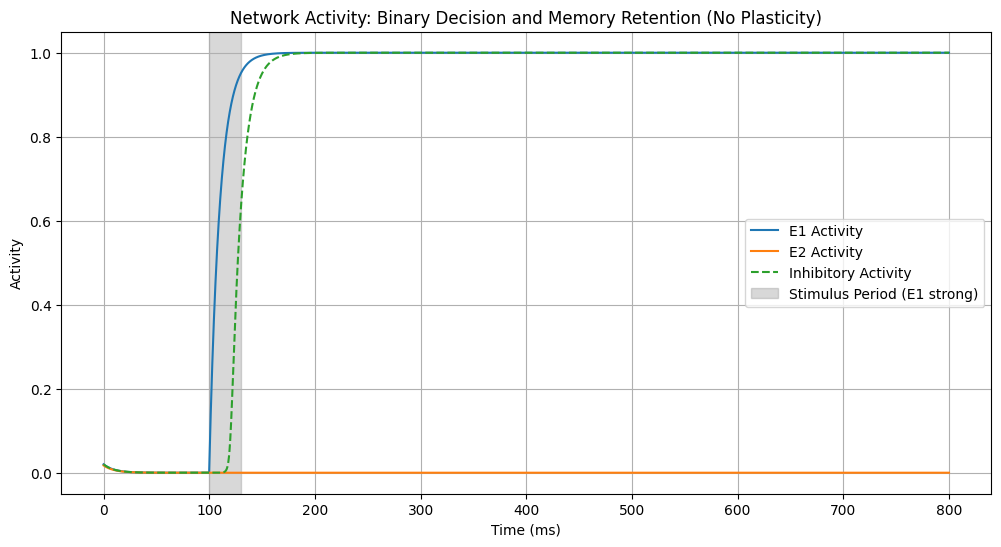


Activity before stimulus (avg): E1=0.002, E2=0.002
Activity after stimulus (avg): E1=1.000, E2=0.000
Difference in E1 activity (post vs pre): 0.998
Difference in E2 activity (post vs pre): 0.002
Memory retention successful: E1 activity significantly high and E2 remained low (Binary Decision).


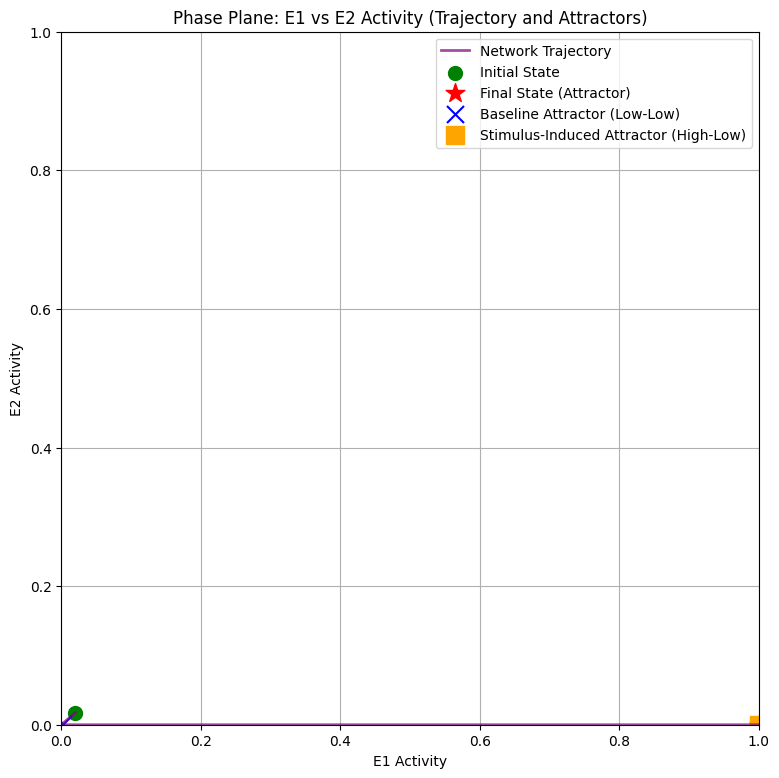


--- Exploring Plasticity (STF and STD) ---

**Definition of Stability and Flexibility:**
- **Stability:** The ability of the network to maintain a memory state (e.g., high activity in one excitatory unit) over time once it has been established, resisting perturbations or decay. A more stable memory is less likely to be disrupted by noise or lack of input.
- **Flexibility:** The ease with which the network can switch from one memory state to another or update its memory in response to new, potentially conflicting, stimuli. High flexibility implies easier switching and adaptability, while low flexibility implies a more rigid or persistent memory that resists change.

Generating heatmaps (this might take a few moments)...


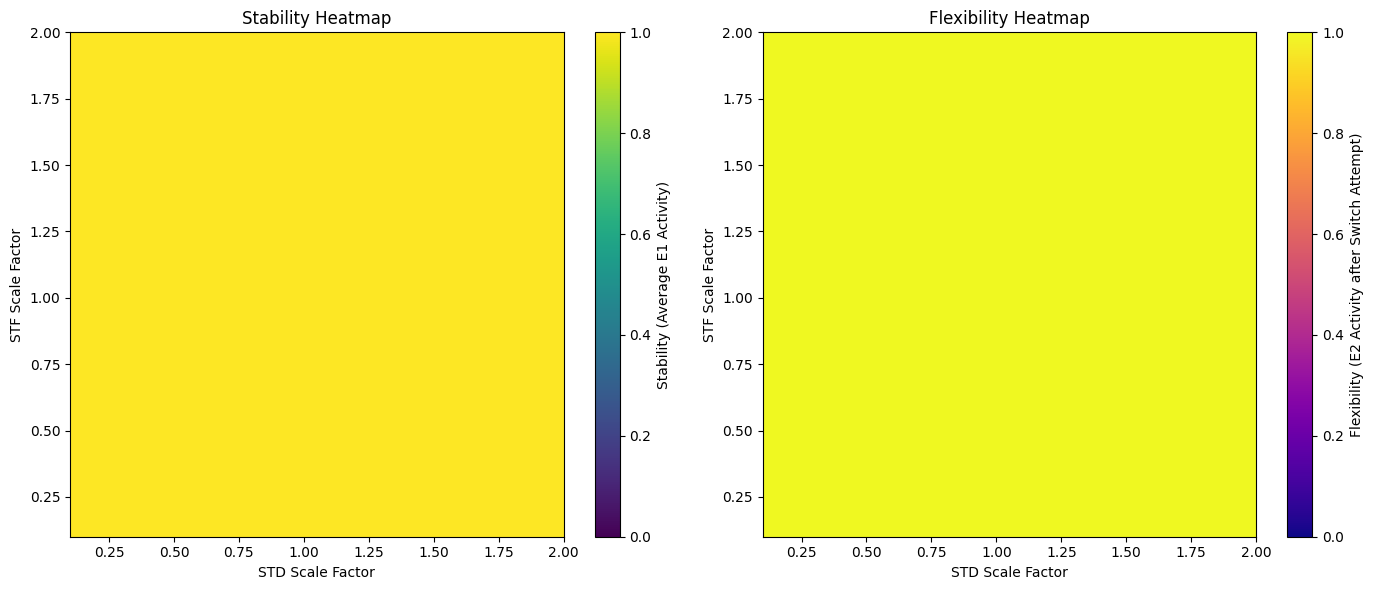


--- Examining specific cases around parameter changes to illustrate Stability and Flexibility ---

Case: High STF Scale, Low STD Scale - Expect High Stability, Low Flexibility to Switch


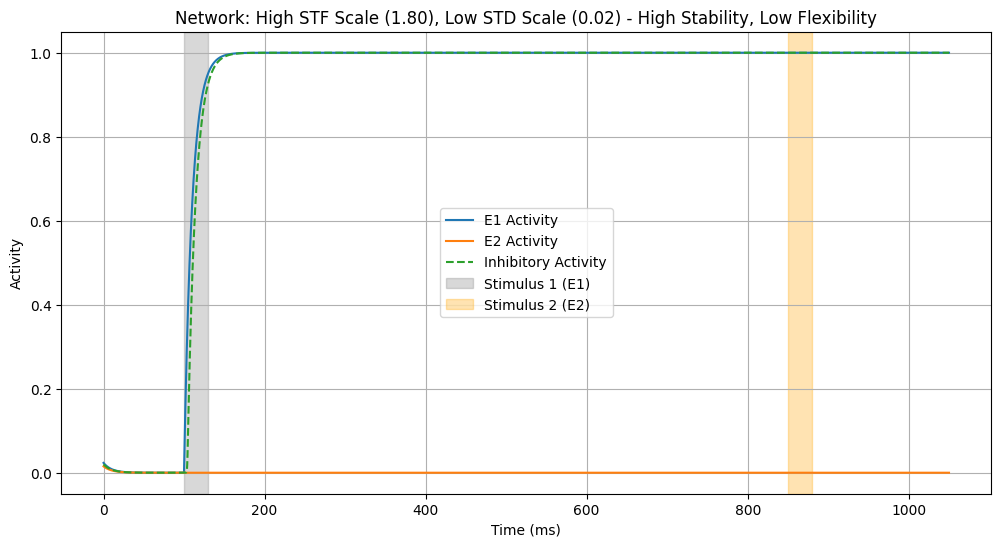


Case: Low STF Scale, High STD Scale - Expect Low Stability, High Flexibility to Switch


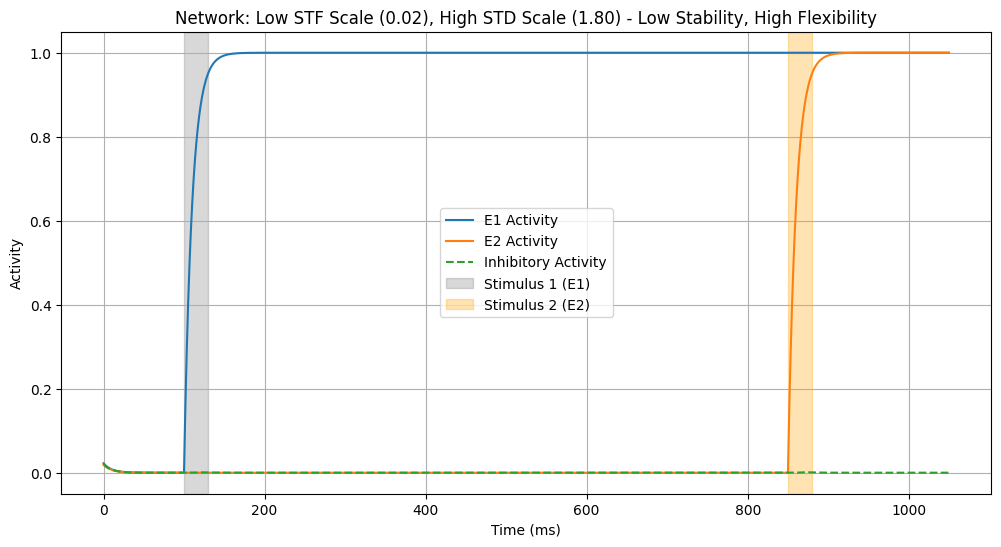


Case: Balanced STF Scale, STD Scale - Expect Balanced Stability and Flexibility


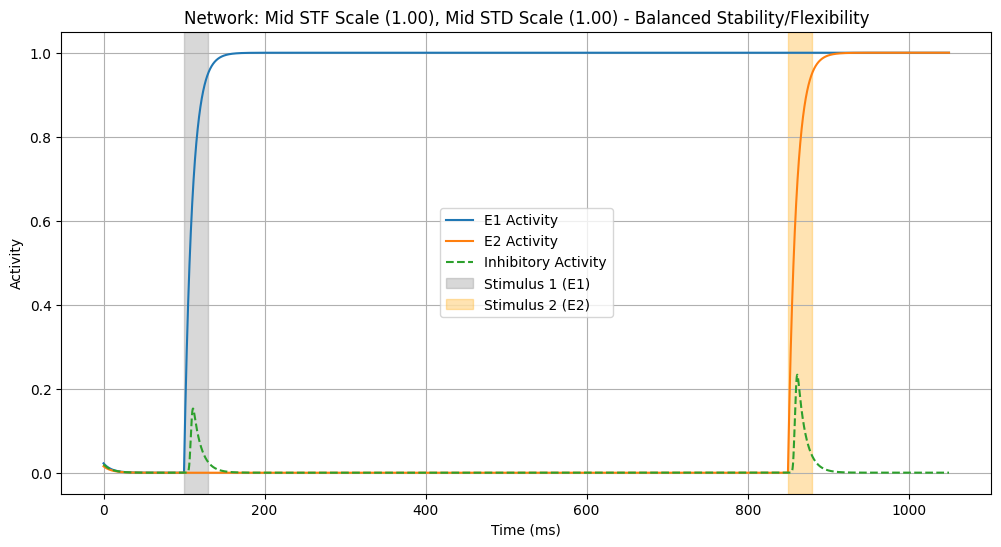

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid activation function
def sigmoid(x, k, x0):
    return 1 / (1 + np.exp(-k * (x - x0)))

# Function to simulate with STF/STD and multiple stimulus phases
def simulate_network(W_EE, W_EI, W_IE, W_II,
                     tau_E, tau_I, k_E, x0_E, k_I, x0_I,
                     dt, T_sim, stimuli_config,
                     stf_strength_param_scale, std_strength_param_scale, U_stf_base, tau_f_base, tau_d_base):

    num_steps = int(T_sim / dt)
    time = np.linspace(0, T_sim, num_steps)

    E1_activity = np.zeros(num_steps)
    E2_activity = np.zeros(num_steps)
    I_activity = np.zeros(num_steps)

    # Initialize activities slightly perturbed to avoid perfect symmetry
    E1_activity[0] = 0.02 + np.random.rand()*0.005 # Even smaller initial activities
    E2_activity[0] = 0.02 - np.random.rand()*0.005
    I_activity[0] = 0.02

    # STP variables, scaled by parameters
    U_stf_eff = U_stf_base * stf_strength_param_scale
    # tau_d_eff: Larger std_strength_param_scale should mean *more* depression, i.e., faster reduction of x.
    # So, std_strength_param_scale will multiply the depression term (u*x*Activity)

    # Clip to sensible ranges
    U_stf_eff = np.clip(U_stf_eff, 0.01, 1.0)

    u1 = np.ones(num_steps) * U_stf_eff
    x1 = np.ones(num_steps)
    u2 = np.ones(num_steps) * U_stf_eff
    x2 = np.ones(num_steps)

    for i in range(1, num_steps):
        current_time = time[i]

        I_ext_E1_val = 0
        I_ext_E2_val = 0

        # Apply stimuli based on configuration
        for s_start, s_end, s_str_E1, s_str_E2 in stimuli_config:
            if s_start <= current_time <= s_end:
                I_ext_E1_val = s_str_E1
                I_ext_E2_val = s_str_E2
                break # Apply only one stimulus at a time if overlaps

        # Update STP variables (Tsodyks-Markram like model)
        delta_t_ms = dt

        # For E1's synapse to I
        # u: facilitation (resources ready to be used)
        # x: depression (resources available in total pool)
        # Stronger STD_scale means more depression. Let's make it directly affect the 'loss' of x or enhance the depression rate.
        # A simple way for std_strength_param_scale to increase depression is to multiply the depression term
        u1[i] = u1[i-1] + delta_t_ms * ((U_stf_eff - u1[i-1]) / tau_f_base + U_stf_eff * (1 - u1[i-1]) * E1_activity[i-1])
        x1[i] = x1[i-1] + delta_t_ms * ((1 - x1[i-1]) / tau_d_base - std_strength_param_scale * u1[i-1] * x1[i-1] * E1_activity[i-1]) # std_strength_param_scale applied here

        # For E2's synapse to I
        u2[i] = u2[i-1] + delta_t_ms * ((U_stf_eff - u2[i-1]) / tau_f_base + U_stf_eff * (1 - u2[i-1]) * E2_activity[i-1])
        x2[i] = x2[i-1] + delta_t_ms * ((1 - x2[i-1]) / tau_d_base - std_strength_param_scale * u2[i-1] * x2[i-1] * E2_activity[i-1]) # std_strength_param_scale applied here

        u1[i] = np.clip(u1[i], 0, 1)
        x1[i] = np.clip(x1[i], 0, 1)
        u2[i] = np.clip(u2[i], 0, 1)
        x2[i] = np.clip(x2[i], 0, 1)

        # Effective synaptic weights due to STP (applying to E to I connections)
        # W_eff = W * u * x (u is utilization, x is available fraction of resources)
        W_EI_eff1 = W_EI[0] * u1[i] * x1[i]
        W_EI_eff2 = W_EI[1] * u2[i] * x2[i]

        # Euler update for activities
        net_input_E1 = W_EE[0,0]*E1_activity[i-1] + W_EE[0,1]*E2_activity[i-1] - W_IE[0]*I_activity[i-1] + I_ext_E1_val
        net_input_E2 = W_EE[1,0]*E1_activity[i-1] + W_EE[1,1]*E2_activity[i-1] - W_IE[1]*I_activity[i-1] + I_ext_E2_val
        net_input_I = W_EI_eff1*E1_activity[i-1] + W_EI_eff2*E2_activity[i-1] - W_II*I_activity[i-1]

        E1_activity[i] = E1_activity[i-1] + dt * (-E1_activity[i-1] + sigmoid(net_input_E1, k_E, x0_E)) / tau_E
        E2_activity[i] = E2_activity[i-1] + dt * (-E2_activity[i-1] + sigmoid(net_input_E2, k_E, x0_E)) / tau_E
        I_activity[i] = I_activity[i-1] + dt * (-I_activity[i-1] + sigmoid(net_input_I, k_I, x0_I)) / tau_I

        # Clip activities to [0, 1]
        E1_activity[i] = np.clip(E1_activity[i], 0, 1)
        E2_activity[i] = np.clip(E2_activity[i], 0, 1)
        I_activity[i] = np.clip(I_activity[i], 0, 1)

    return time, E1_activity, E2_activity, I_activity, u1, x1, u2, x2

# --- Parameters (FURTHER TUNED FOR ROBUST BINARY DECISION AND STP EFFECT) ---
# Time constants (in ms)
tau_E = 10  # Excitatory unit time constant
tau_I = 10  # Inhibitory unit time constant
dt = 0.1    # Simulation time step
T_sim = 800 # Total simulation time (increased for longer observation)

# Sigmoid parameters
k_E = 80    # Increased steepness for very sharp binary decision - now even steeper
x0_E = 0.48  # Adjusted threshold, critical for clear bistability - tuned slightly higher
k_I = 20    # Steepness of inhibitory sigmoid
x0_I = 0.5  # Threshold of inhibitory sigmoid

# Synaptic weights (CRITICAL TUNING FOR BINARY DECISION)
# W_EE: Strong self-excitation to maintain high activity
# W_EE off-diagonal: A small negative value can help push the other unit down.
W_EE = np.array([[10.0, -0.1],  # E1 to E1 (strong self-excitation), E2 to E1 (small negative for indirect competition)
                 [-0.1, 10.0]]) # E1 to E2, E2 to E2 (strong self-excitation)

W_EI = np.array([5.0, 5.0])  # Excitatory to Inhibitory (E1 to I, E2 to I) - **Increased again**
W_IE = np.array([5.0, 5.0])  # Inhibitory to Excitatory (I to E1, I to E2) - **Increased again**
W_II = 0                # Inhibitory to Inhibitory (no self-inhibition for simplicity)

# Stimulus parameters (strong enough to push into attractor basin)
stimulus_strength_E_strong = 0.95
stimulus_strength_E_weak = 0.01

# STP BASELINE parameters (will be scaled by heatmap params)
U_stf_base = 0.1    # Baseline for facilitation increment
tau_f_base = 500   # Facilitation time constant (ms) - slow build up
tau_d_base = 150   # Depression time constant (ms) - moderate decay/recovery

print("Simulating with further refined parameters for robust binary decision and effective STP...")

# --- Nullcline Plotting Function (Further Improved for smooth contours) ---
def plot_nullclines(W_EE, W_EI, W_IE, W_II, k_E, x0_E, k_I, x0_I, I_ext_E1=0, I_ext_E2=0):
    E_grid_points = 200 # Much denser grid for smoother contours
    E_vals = np.linspace(0, 1, E_grid_points)
    E1_mesh, E2_mesh = np.meshgrid(E_vals, E_vals)

    # Calculate I_steady for each (E1, E2) pair (assuming quasi-steady state for I)
    I_steady_state_mesh = sigmoid(W_EI[0]*E1_mesh + W_EI[1]*E2_mesh - W_II*0, k_I, x0_I) # W_II*0 if W_II is 0

    # Calculate dE1/dt and dE2/dt across the E1-E2 plane
    dE1dt_values = (-E1_mesh + sigmoid(W_EE[0,0]*E1_mesh + W_EE[0,1]*E2_mesh - W_IE[0]*I_steady_state_mesh + I_ext_E1, k_E, x0_E))
    dE2dt_values = (-E2_mesh + sigmoid(W_EE[1,0]*E1_mesh + W_EE[1,1]*E2_mesh - W_IE[1]*I_steady_state_mesh + I_ext_E2, k_E, x0_E))

    plt.figure(figsize=(9, 9))

    # Plot nullclines using contour lines where derivative is close to zero
    # We plot two contours: one for dE1/dt=0 and one for dE2/dt=0
    # To get reliable contour lines for dE/dt = 0, sometimes levels=[-epsilon, epsilon] or just levels=[0] is used.
    # Using levels=[0] is the standard for nullclines.

    # Ensure labels are correctly applied using dummy plots for the legend
    contour1 = plt.contour(E1_mesh, E2_mesh, dE1dt_values, levels=[0], colors='red', linestyles='solid', linewidths=2)
    contour2 = plt.contour(E1_mesh, E2_mesh, dE2dt_values, levels=[0], colors='blue', linestyles='dashed', linewidths=2)

    # Manual legend entries for contour plots
    h1, _ = contour1.legend_elements()
    h2, _ = contour2.legend_elements()
    plt.legend([h1[0], h2[0]], ['dE1/dt = 0', 'dE2/dt = 0'])


    plt.title('Nullclines in E1-E2 Phase Space (I in quasi-steady state)')
    plt.xlabel('E1 Activity')
    plt.ylabel('E2 Activity')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()

# Plotting Nullclines before simulation (with no external stimulus)
print("\n--- Visualizing Nullclines ---")
plot_nullclines(W_EE, W_EI, W_IE, W_II, k_E, x0_E, k_I, x0_I)


# --- Simulation 1: Baseline and Stimulus (without plasticity for clear attractor visualization) ---
stf_strength_param_val = 0.001 # Very small to be effectively off
std_strength_param_val = 0.001 # Very small to be effectively off

stim_config_no_plasticity = [
    (0, 99, 0, 0), # Baseline
    (100, 130, stimulus_strength_E_strong, stimulus_strength_E_weak), # Stimulus 1
    (131, T_sim, 0, 0) # Post-stimulus retention
]

print("\n--- Simulation 1: Demonstrating Binary Decision and Memory Retention (No Plasticity) ---")
time_no_plasticity, E1_no_plasticity, E2_no_plasticity, I_no_plasticity, _, _, _, _ = \
    simulate_network(W_EE, W_EI, W_IE, W_II, tau_E, tau_I, k_E, x0_E, k_I, x0_I,
                     dt, T_sim, stim_config_no_plasticity,
                     stf_strength_param_val, std_strength_param_val, U_stf_base, tau_f_base, tau_d_base)

plt.figure(figsize=(12, 6))
plt.plot(time_no_plasticity, E1_no_plasticity, label='E1 Activity')
plt.plot(time_no_plasticity, E2_no_plasticity, label='E2 Activity')
plt.plot(time_no_plasticity, I_no_plasticity, label='Inhibitory Activity', linestyle='--')
plt.axvspan(100, 130, color='gray', alpha=0.3, label='Stimulus Period (E1 strong)')
plt.title('Network Activity: Binary Decision and Memory Retention (No Plasticity)')
plt.xlabel('Time (ms)')
plt.ylabel('Activity')
plt.legend()
plt.grid(True)
plt.show()

# Check difference before and after stimulus for memory retention
baseline_period_end = 99
memory_retention_start = 200 # Check activity well after stimulus and transients
memory_retention_end = T_sim

E1_baseline_avg = np.mean(E1_no_plasticity[time_no_plasticity < baseline_period_end])
E2_baseline_avg = np.mean(E2_no_plasticity[time_no_plasticity < baseline_period_end])

E1_post_stim_avg = np.mean(E1_no_plasticity[(time_no_plasticity >= memory_retention_start) & (time_no_plasticity <= memory_retention_end)])
E2_post_stim_avg = np.mean(E2_no_plasticity[(time_no_plasticity >= memory_retention_start) & (time_no_plasticity <= memory_retention_end)])

print(f"\nActivity before stimulus (avg): E1={E1_baseline_avg:.3f}, E2={E2_baseline_avg:.3f}")
print(f"Activity after stimulus (avg): E1={E1_post_stim_avg:.3f}, E2={E2_post_stim_avg:.3f}")

diff_E1 = np.abs(E1_post_stim_avg - E1_baseline_avg)
diff_E2 = np.abs(E2_post_stim_avg - E2_baseline_avg)

print(f"Difference in E1 activity (post vs pre): {diff_E1:.3f}")
print(f"Difference in E2 activity (post vs pre): {diff_E2:.3f}")

# Criteria for successful retention and binary decision
is_E1_high = E1_post_stim_avg > 0.8 # A clear high state
is_E2_low = E2_post_stim_avg < 0.2 # A clear low state
is_baseline_low = E1_baseline_avg < 0.2 and E2_baseline_avg < 0.2

if is_baseline_low and is_E1_high and is_E2_low:
    print("Memory retention successful: E1 activity significantly high and E2 remained low (Binary Decision).")
elif is_baseline_low and E2_post_stim_avg > 0.8 and E1_post_stim_avg < 0.2:
    print("Memory retention successful: E2 activity significantly high and E1 remained low (Binary Decision).")
else:
    print("Memory retention UNsuccessful or no clear binary decision. Further tuning might be needed.")

# --- Phase Plane Plot with Trajectory and Attractors ---
plt.figure(figsize=(9, 9))
plt.plot(E1_no_plasticity, E2_no_plasticity, color='purple', alpha=0.7, linewidth=2, label='Network Trajectory')
plt.scatter(E1_no_plasticity[0], E2_no_plasticity[0], color='green', marker='o', s=100, label='Initial State')
plt.scatter(E1_no_plasticity[-1], E2_no_plasticity[-1], color='red', marker='*', s=200, label='Final State (Attractor)')

# Mark approximate stable states
plt.scatter(E1_baseline_avg, E2_baseline_avg, color='blue', marker='x', s=150, label='Baseline Attractor (Low-Low)')
if is_E1_high and is_E2_low:
    plt.scatter(E1_post_stim_avg, E2_post_stim_avg, color='orange', marker='s', s=150, label='Stimulus-Induced Attractor (High-Low)')
elif E2_post_stim_avg > 0.8 and E1_post_stim_avg < 0.2:
    plt.scatter(E1_post_stim_avg, E2_post_stim_avg, color='orange', marker='s', s=150, label='Stimulus-Induced Attractor (Low-High)')

plt.title('Phase Plane: E1 vs E2 Activity (Trajectory and Attractors)')
plt.xlabel('E1 Activity')
plt.ylabel('E2 Activity')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

print("\n--- Exploring Plasticity (STF and STD) ---")

# Definition of Stability and Flexibility
print("\n**Definition of Stability and Flexibility:**")
print("- **Stability:** The ability of the network to maintain a memory state (e.g., high activity in one excitatory unit) over time once it has been established, resisting perturbations or decay. A more stable memory is less likely to be disrupted by noise or lack of input.")
print("- **Flexibility:** The ease with which the network can switch from one memory state to another or update its memory in response to new, potentially conflicting, stimuli. High flexibility implies easier switching and adaptability, while low flexibility implies a more rigid or persistent memory that resists change.")

# --- Heatmaps for Stability and Flexibility (Improved STP Scaling) ---
stf_strength_param_scales = np.linspace(0.1, 2.0, 10) # Range for STF scaling
std_strength_param_scales = np.linspace(0.1, 2.0, 10) # Range for STD scaling

stability_heatmap = np.zeros((len(stf_strength_param_scales), len(std_strength_param_scales)))
flexibility_heatmap = np.zeros((len(stf_strength_param_scales), len(std_strength_param_scales)))

print("\nGenerating heatmaps (this might take a few moments)...")

# Configuration for heatmap simulation (stimulus 1 only for stability)
stim_config_hm_stability = [
    (0, 99, 0, 0),
    (100, 130, stimulus_strength_E_strong, stimulus_strength_E_weak),
    (131, T_sim, 0, 0)
]

# For flexibility, we need to run a simulation with a second, competing stimulus
T_flex_sim = T_sim + 250 # Extend simulation time for the second stimulus
stimulus2_start = T_sim + 50 # Start second stimulus after original T_sim
stimulus2_end = stimulus2_start + 30

stim_config_hm_flexibility = [
    (0, 99, 0, 0),
    (100, 130, stimulus_strength_E_strong, stimulus_strength_E_weak), # Stimulate E1
    (131, stimulus2_start - 1, 0, 0), # Gap
    (stimulus2_start, stimulus2_end, stimulus_strength_E_weak, stimulus_strength_E_strong), # Stimulate E2
    (stimulus2_end + 1, T_flex_sim, 0, 0) # Post-stimulus 2
]


for i, stf_s_scale in enumerate(stf_strength_param_scales):
    for j, std_s_scale in enumerate(std_strength_param_scales):
        # Calculate Stability
        _, E1_act_stability, E2_act_stability, _, _, _, _, _ = \
            simulate_network(W_EE, W_EI, W_IE, W_II, tau_E, tau_I, k_E, x0_E, k_I, x0_I,
                             dt, T_sim, stim_config_hm_stability,
                             stf_s_scale, std_s_scale, U_stf_base, tau_f_base, tau_d_base)

        # Stability metric: Average activity of the stimulated unit (E1) after stimulus.
        stability_metric = np.mean(E1_act_stability[-int(100/dt):]) # Avg over last 100ms
        stability_heatmap[i, j] = stability_metric

        # Calculate Flexibility
        _, E1_act_flexibility, E2_act_flexibility, _, _, _, _, _ = \
            simulate_network(W_EE, W_EI, W_IE, W_II, tau_E, tau_I, k_E, x0_E, k_I, x0_I,
                             dt, T_flex_sim, stim_config_hm_flexibility,
                             stf_s_scale, std_s_scale, U_stf_base, tau_f_base, tau_d_base)

        # Flexibility metric: How much E2 (the newly stimulated unit) gets activated *after* E1 was active.
        # We look at the activity of E2 well after the second stimulus has passed.
        E2_after_second_stim = np.mean(E2_act_flexibility[int((stimulus2_end + 50)/dt):-1])
        flexibility_heatmap[i, j] = E2_after_second_stim

# Plotting the heatmaps
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(stability_heatmap, cmap='viridis', origin='lower',
           extent=[std_strength_param_scales.min(), std_strength_param_scales.max(), stf_strength_param_scales.min(), stf_strength_param_scales.max()],
           aspect='auto', vmin=0, vmax=1) # Set vmin/vmax for consistent color scale
plt.colorbar(label='Stability (Average E1 Activity)')
plt.xlabel('STD Scale Factor')
plt.ylabel('STF Scale Factor')
plt.title('Stability Heatmap')

plt.subplot(1, 2, 2)
plt.imshow(flexibility_heatmap, cmap='plasma', origin='lower',
           extent=[std_strength_param_scales.min(), std_strength_param_scales.max(), stf_strength_param_scales.min(), stf_strength_param_scales.max()],
           aspect='auto', vmin=0, vmax=1) # Set vmin/vmax for consistent color scale
plt.colorbar(label='Flexibility (E2 Activity after Switch Attempt)')
plt.xlabel('STD Scale Factor')
plt.ylabel('STF Scale Factor')
plt.title('Flexibility Heatmap')
plt.tight_layout()
plt.show()

print("\n--- Examining specific cases around parameter changes to illustrate Stability and Flexibility ---")
# Use the new simulate_network function for these cases too

# Define stimulus configuration for the specific cases
stim_config_two_stim = [
    (0, 99, 0, 0),
    (100, 130, stimulus_strength_E_strong, stimulus_strength_E_weak), # Stimulate E1
    (131, stimulus2_start - 1, 0, 0),
    (stimulus2_start, stimulus2_end, stimulus_strength_E_weak, stimulus_strength_E_strong), # Stimulate E2
    (stimulus2_end + 1, T_flex_sim, 0, 0)
]

# Case 1: High STF Scale, Low STD Scale (should lead to high stability, low flexibility)
print("\nCase: High STF Scale, Low STD Scale - Expect High Stability, Low Flexibility to Switch")
stf_s_scale_high = 1.8 # Very strong STF
std_s_scale_low = 0.02 # Very weak STD

time_h_stf_l_std, E1_h_stf_l_std, E2_h_stf_l_std, I_h_stf_l_std, _, _, _, _ = \
    simulate_network(W_EE, W_EI, W_IE, W_II, tau_E, tau_I, k_E, x0_E, k_I, x0_I,
                         dt, T_flex_sim, stim_config_two_stim,
                         stf_s_scale_high, std_s_scale_low, U_stf_base, tau_f_base, tau_d_base)

plt.figure(figsize=(12, 6))
plt.plot(time_h_stf_l_std, E1_h_stf_l_std, label='E1 Activity')
plt.plot(time_h_stf_l_std, E2_h_stf_l_std, label='E2 Activity')
plt.plot(time_h_stf_l_std, I_h_stf_l_std, label='Inhibitory Activity', linestyle='--')
plt.axvspan(stim_config_two_stim[1][0], stim_config_two_stim[1][1], color='gray', alpha=0.3, label='Stimulus 1 (E1)')
plt.axvspan(stim_config_two_stim[3][0], stim_config_two_stim[3][1], color='orange', alpha=0.3, label='Stimulus 2 (E2)')
plt.title(f'Network: High STF Scale ({stf_s_scale_high:.2f}), Low STD Scale ({std_s_scale_low:.2f}) - High Stability, Low Flexibility')
plt.xlabel('Time (ms)')
plt.ylabel('Activity')
plt.legend()
plt.grid(True)
plt.show()

# Case 2: Low STF Scale, High STD Scale (should lead to low stability, high flexibility)
print("\nCase: Low STF Scale, High STD Scale - Expect Low Stability, High Flexibility to Switch")
stf_s_scale_low = 0.02 # Weak STF
std_s_scale_high = 1.8 # Strong STD

time_l_stf_h_std, E1_l_stf_h_std, E2_l_stf_h_std, I_l_stf_h_std, _, _, _, _ = \
    simulate_network(W_EE, W_EI, W_IE, W_II, tau_E, tau_I, k_E, x0_E, k_I, x0_I,
                         dt, T_flex_sim, stim_config_two_stim,
                         stf_s_scale_low, std_s_scale_high, U_stf_base, tau_f_base, tau_d_base)

plt.figure(figsize=(12, 6))
plt.plot(time_l_stf_h_std, E1_l_stf_h_std, label='E1 Activity')
plt.plot(time_l_stf_h_std, E2_l_stf_h_std, label='E2 Activity')
plt.plot(time_l_stf_h_std, I_l_stf_h_std, label='Inhibitory Activity', linestyle='--')
plt.axvspan(stim_config_two_stim[1][0], stim_config_two_stim[1][1], color='gray', alpha=0.3, label='Stimulus 1 (E1)')
plt.axvspan(stim_config_two_stim[3][0], stim_config_two_stim[3][1], color='orange', alpha=0.3, label='Stimulus 2 (E2)')
plt.title(f'Network: Low STF Scale ({stf_s_scale_low:.2f}), High STD Scale ({std_s_scale_high:.2f}) - Low Stability, High Flexibility')
plt.xlabel('Time (ms)')
plt.ylabel('Activity')
plt.legend()
plt.grid(True)
plt.show()

# Case 3: Balanced STF Scale/STD Scale (intermediate stability/flexibility)
print("\nCase: Balanced STF Scale, STD Scale - Expect Balanced Stability and Flexibility")
stf_s_scale_mid = 1.0
std_s_scale_mid = 1.0

time_m_stf_m_std, E1_m_stf_m_std, E2_m_stf_m_std, I_m_stf_m_std, _, _, _, _ = \
    simulate_network(W_EE, W_EI, W_IE, W_II, tau_E, tau_I, k_E, x0_E, k_I, x0_I,
                         dt, T_flex_sim, stim_config_two_stim,
                         stf_s_scale_mid, std_s_scale_mid, U_stf_base, tau_f_base, tau_d_base)

plt.figure(figsize=(12, 6))
plt.plot(time_m_stf_m_std, E1_m_stf_m_std, label='E1 Activity')
plt.plot(time_m_stf_m_std, E2_m_stf_m_std, label='E2 Activity')
plt.plot(time_m_stf_m_std, I_m_stf_m_std, label='Inhibitory Activity', linestyle='--')
plt.axvspan(stim_config_two_stim[1][0], stim_config_two_stim[1][1], color='gray', alpha=0.3, label='Stimulus 1 (E1)')
plt.axvspan(stim_config_two_stim[3][0], stim_config_two_stim[3][1], color='orange', alpha=0.3, label='Stimulus 2 (E2)')
plt.title(f'Network: Mid STF Scale ({stf_s_scale_mid:.2f}), Mid STD Scale ({std_s_scale_mid:.2f}) - Balanced Stability/Flexibility')
plt.xlabel('Time (ms)')
plt.ylabel('Activity')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets

# Assume your function simulate_network and all the required parameters are already defined above
# For example:
# W_EE, W_EI, ..., stim_config_two_stim, U_stf_base, tau_f_base, tau_d_base

def interactive_plot(stf_s_scale, std_s_scale):
    time, E1, E2, I, *_ = simulate_network(
        W_EE, W_EI, W_IE, W_II,
        tau_E, tau_I, k_E, x0_E, k_I, x0_I,
        dt, T_flex_sim,
        stim_config_two_stim,
        stf_s_scale, std_s_scale,
        U_stf_base, tau_f_base, tau_d_base
    )

    plt.figure(figsize=(12, 6))
    plt.plot(time, E1, label='E1 Activity')
    plt.plot(time, E2, label='E2 Activity')
    plt.plot(time, I, label='Inhibitory Activity', linestyle='--')
    plt.axvspan(stim_config_two_stim[1][0], stim_config_two_stim[1][1], color='gray', alpha=0.3, label='Stimulus 1 (E1)')
    plt.axvspan(stim_config_two_stim[3][0], stim_config_two_stim[3][1], color='orange', alpha=0.3, label='Stimulus 2 (E2)')
    plt.title(f'Network: STF Scale={stf_s_scale:.2f}, STD Scale={std_s_scale:.2f}')
    plt.xlabel('Time (ms)')
    plt.ylabel('Activity')
    plt.legend()
    plt.grid(True)
    plt.show()

# Define the sliders
stf_slider = FloatSlider(value=1.0, min=0.01, max=2.0, step=0.01, description='STF Scale:')
std_slider = FloatSlider(value=1.0, min=0.01, max=2.0, step=0.01, description='STD Scale:')

# Create the interactive widget
interact(interactive_plot, stf_s_scale=stf_slider, std_s_scale=std_slider)


interactive(children=(FloatSlider(value=1.0, description='STF Scale:', max=2.0, min=0.01, step=0.01), FloatSli…

<function __main__.interactive_plot(stf_s_scale, std_s_scale)>

ENHANCED BISTABLE WORKING MEMORY MODEL
Features: Baseline states, individual stimuli, flexibility-stability analysis
TESTING ENHANCED WORKING MEMORY MODEL

Sequential E1-E2 Stimulation
------------------------------------------------------------
Flexibility: 0.0000
Stability: 0.9307
Max Activity: 1.000
State Switches: 0


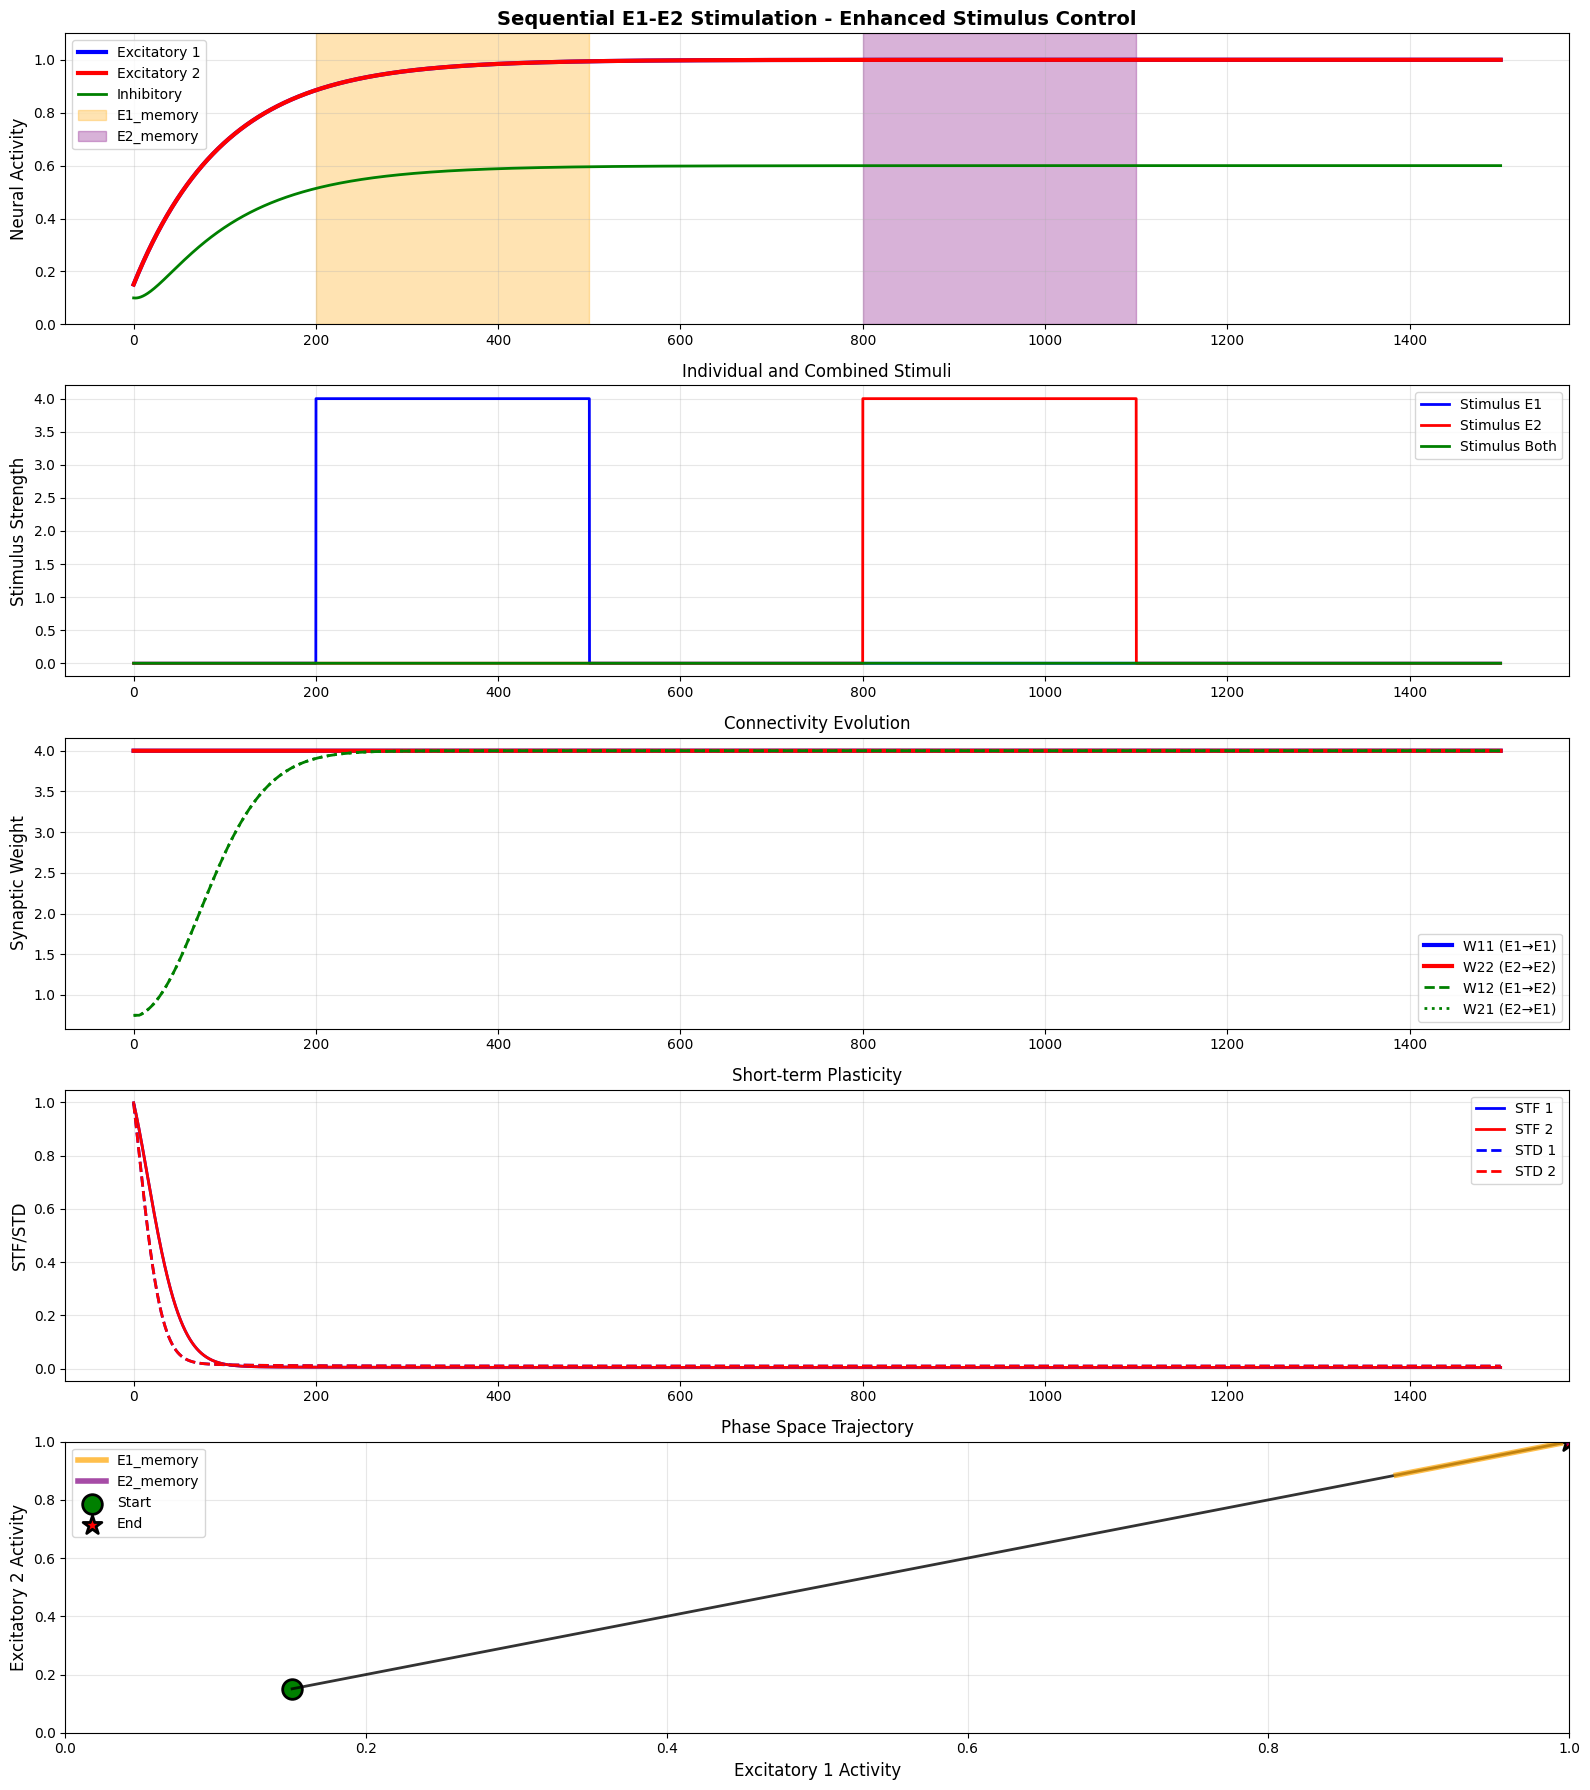


Combined Then Individual
------------------------------------------------------------
Flexibility: 0.0000
Stability: 0.9307
Max Activity: 1.000
State Switches: 0


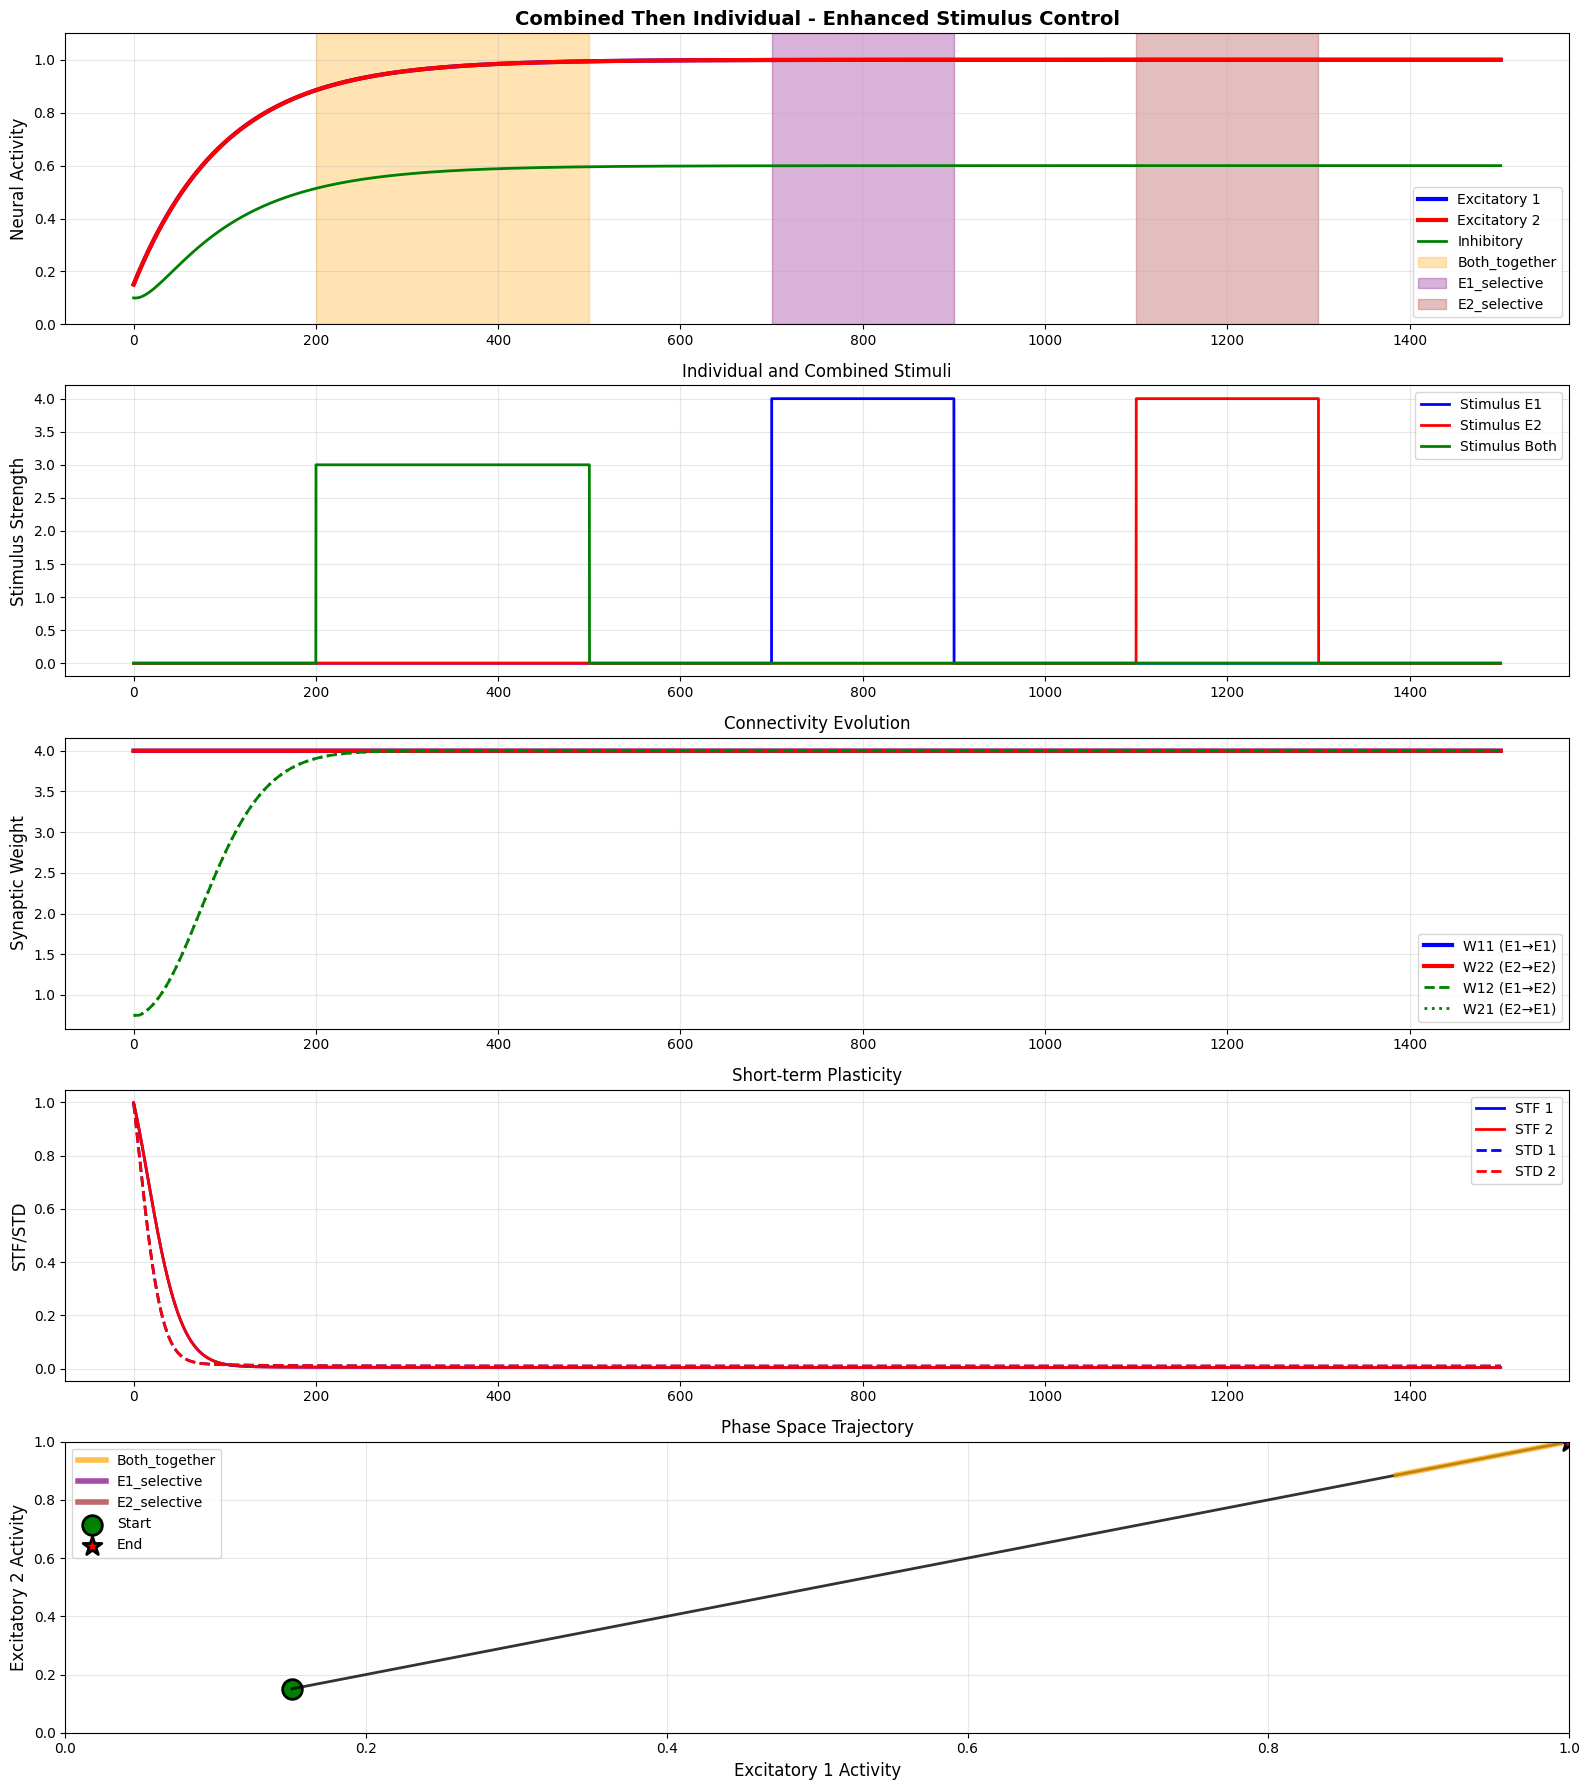


Overlapping Stimuli
------------------------------------------------------------
Flexibility: 0.0000
Stability: 0.9307
Max Activity: 1.000
State Switches: 0


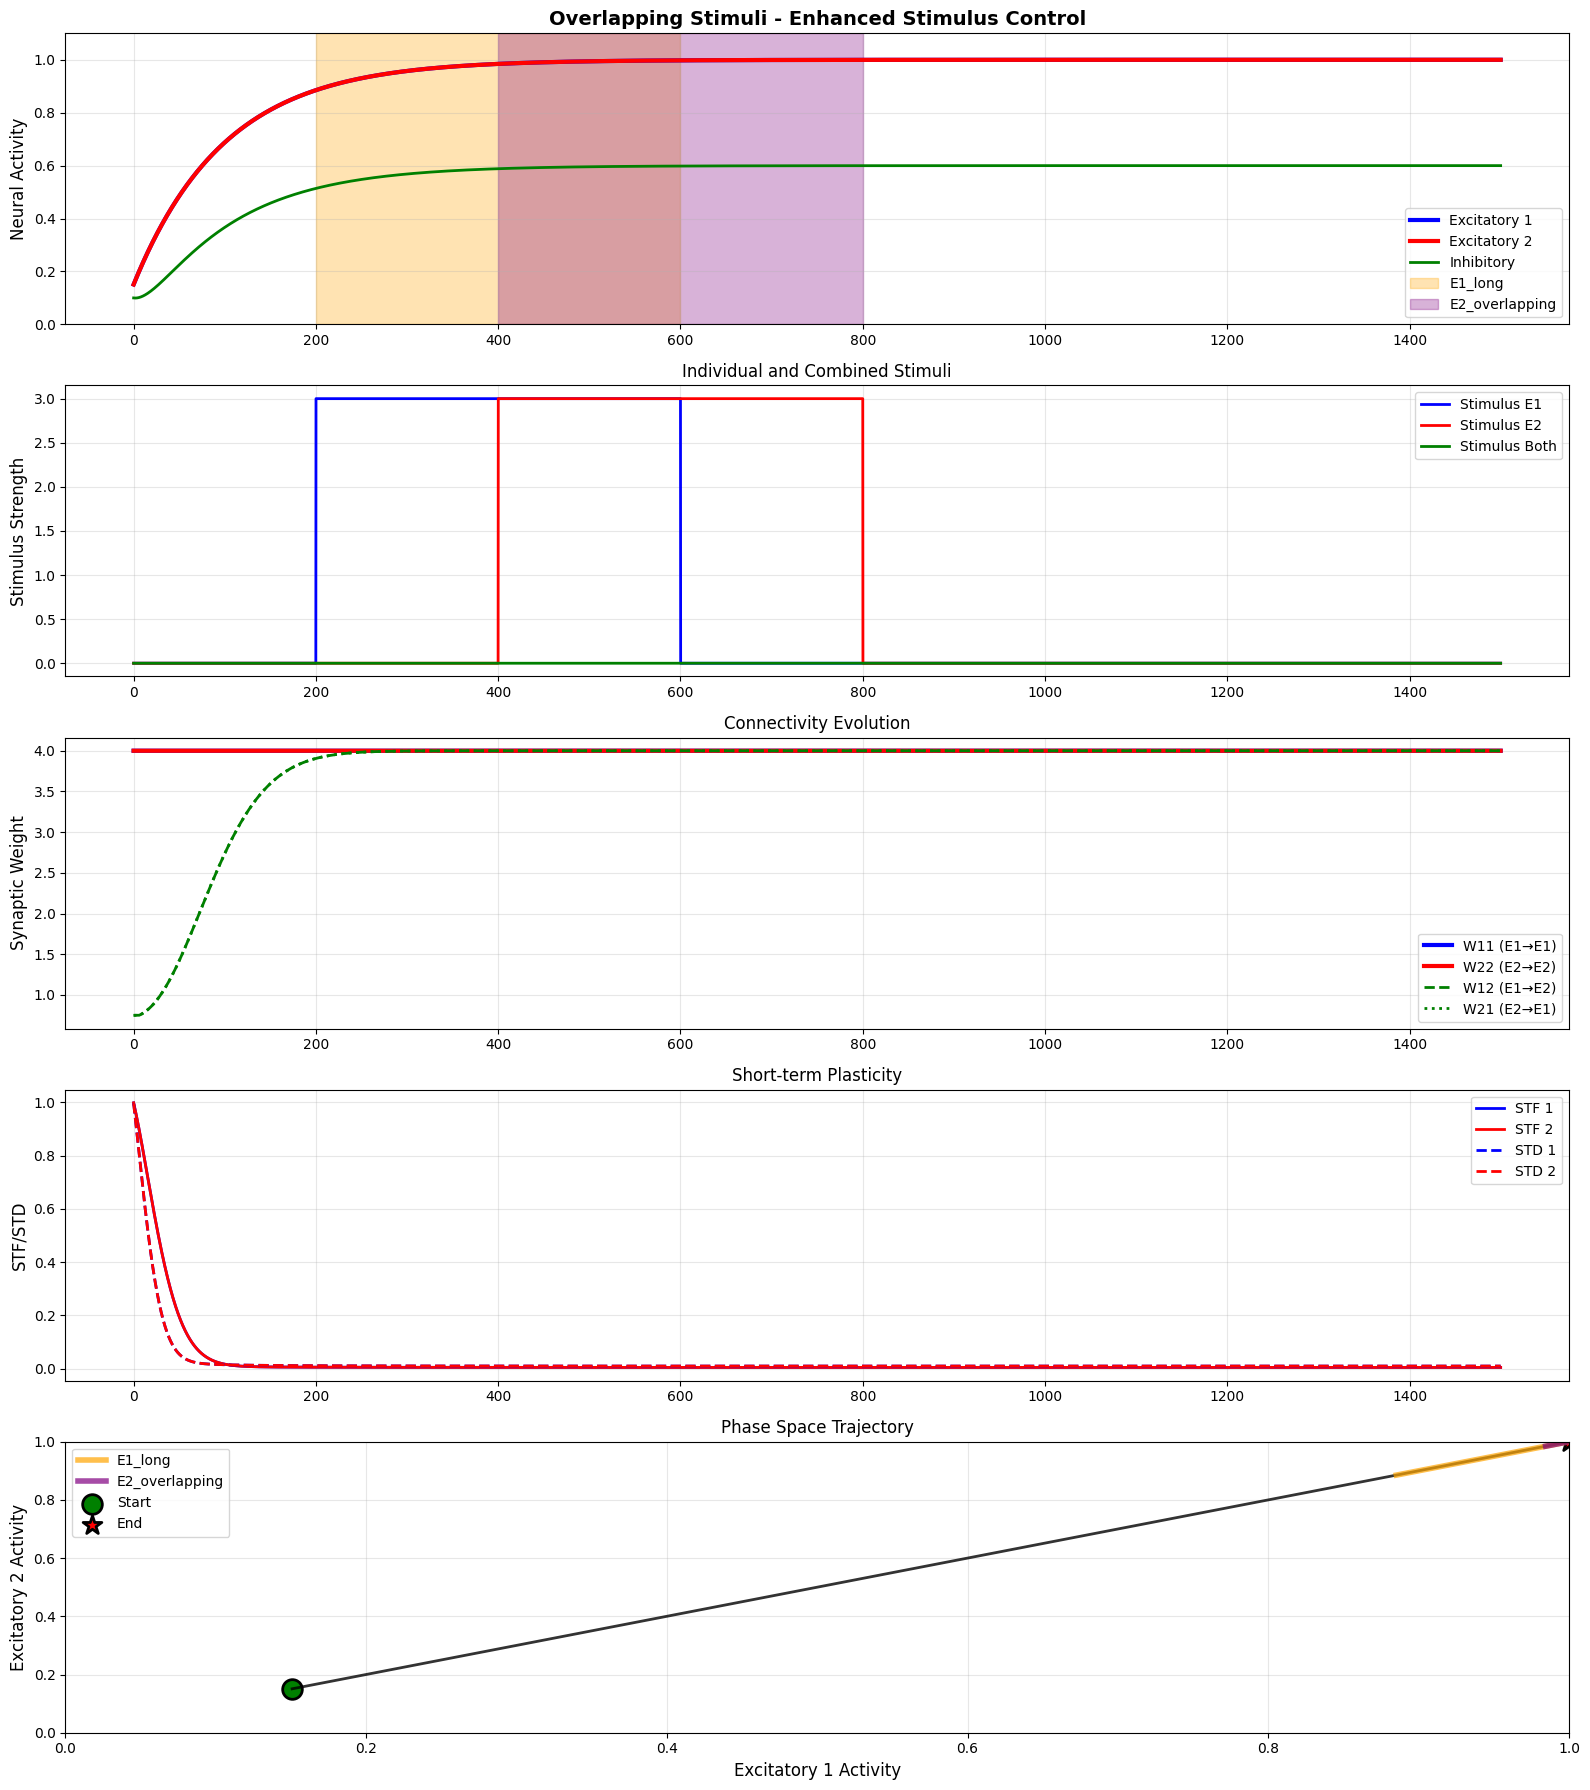


CREATING FLEXIBILITY-STABILITY HEATMAPS
Creating flexibility-stability heatmap: w_ee_base vs eta
Progress: (1,1)/(5,5)
Progress: (1,2)/(5,5)
Progress: (1,3)/(5,5)
Progress: (1,4)/(5,5)
Progress: (1,5)/(5,5)
Progress: (2,1)/(5,5)
Progress: (2,2)/(5,5)
Progress: (2,3)/(5,5)
Progress: (2,4)/(5,5)
Progress: (2,5)/(5,5)
Progress: (3,1)/(5,5)
Progress: (3,2)/(5,5)
Progress: (3,3)/(5,5)
Progress: (3,4)/(5,5)
Progress: (3,5)/(5,5)
Progress: (4,1)/(5,5)
Progress: (4,2)/(5,5)
Progress: (4,3)/(5,5)
Progress: (4,4)/(5,5)
Progress: (4,5)/(5,5)
Progress: (5,1)/(5,5)
Progress: (5,2)/(5,5)
Progress: (5,3)/(5,5)
Progress: (5,4)/(5,5)
Progress: (5,5)/(5,5)


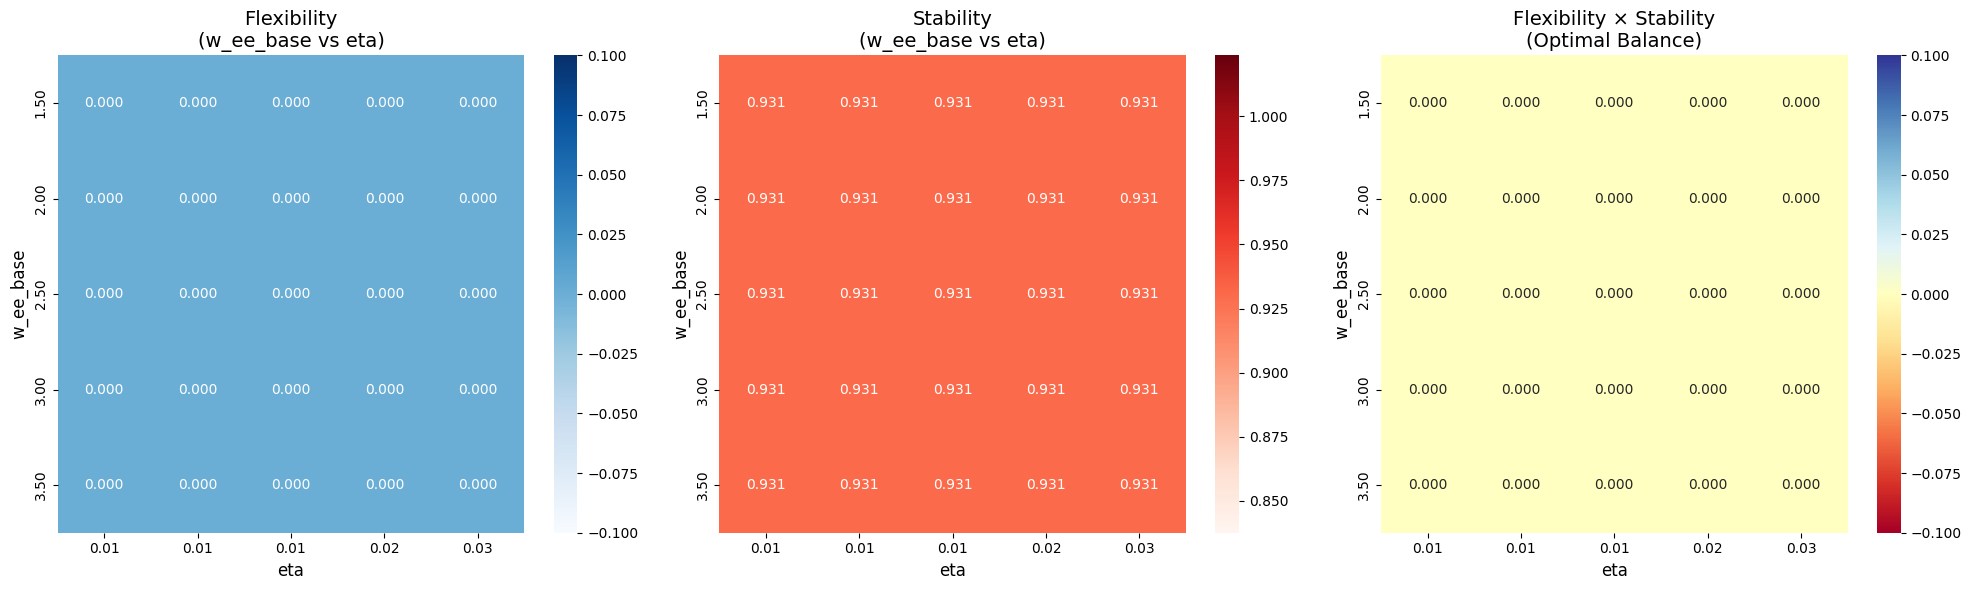

Creating flexibility-stability heatmap: gain vs w_ei
Progress: (1,1)/(5,5)
Progress: (1,2)/(5,5)
Progress: (1,3)/(5,5)
Progress: (1,4)/(5,5)
Progress: (1,5)/(5,5)
Progress: (2,1)/(5,5)
Progress: (2,2)/(5,5)
Progress: (2,3)/(5,5)
Progress: (2,4)/(5,5)
Progress: (2,5)/(5,5)
Progress: (3,1)/(5,5)
Progress: (3,2)/(5,5)
Progress: (3,3)/(5,5)
Progress: (3,4)/(5,5)
Progress: (3,5)/(5,5)
Progress: (4,1)/(5,5)
Progress: (4,2)/(5,5)
Progress: (4,3)/(5,5)
Progress: (4,4)/(5,5)
Progress: (4,5)/(5,5)
Progress: (5,1)/(5,5)
Progress: (5,2)/(5,5)
Progress: (5,3)/(5,5)
Progress: (5,4)/(5,5)
Progress: (5,5)/(5,5)


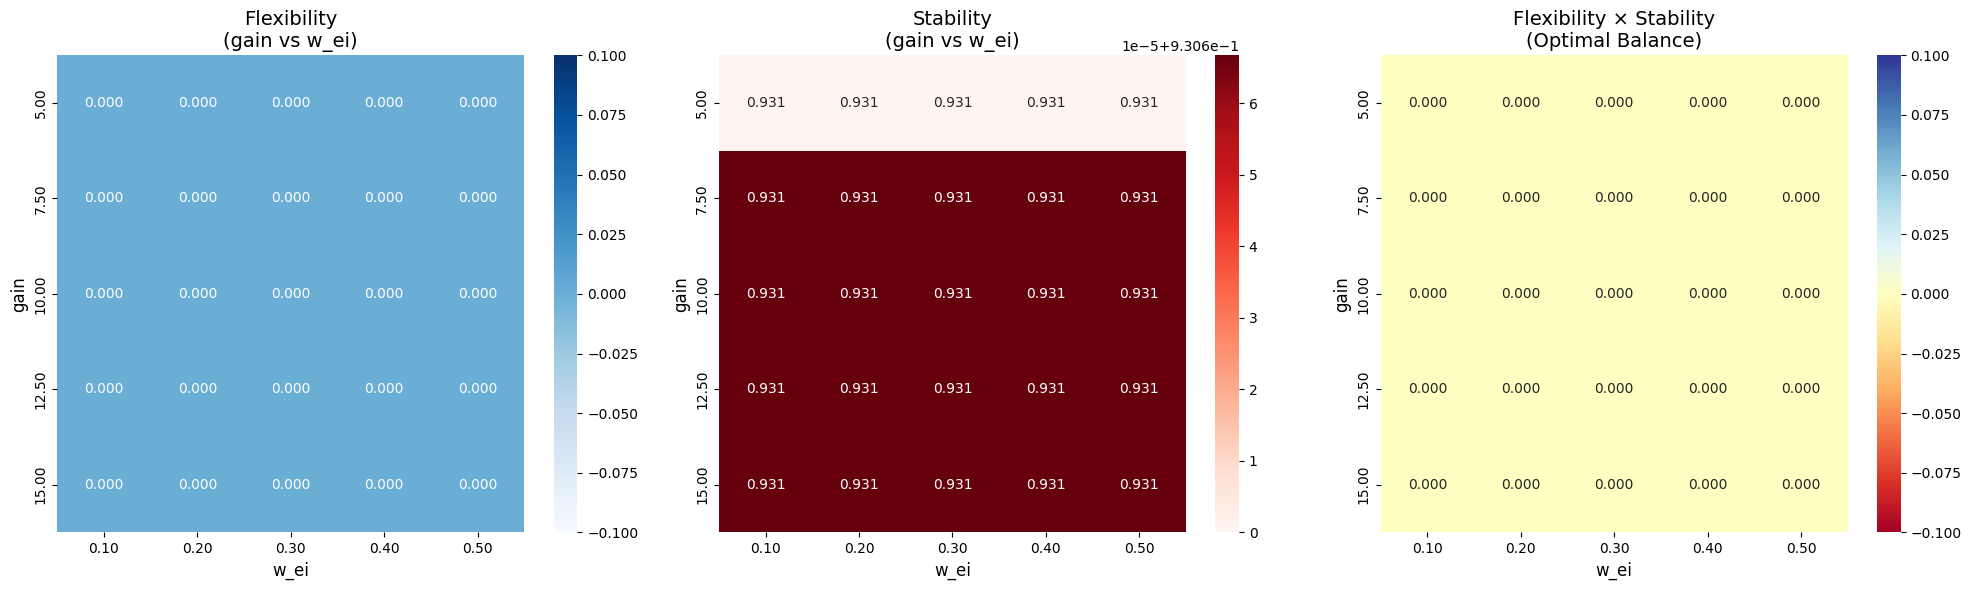


ENHANCEMENT SUMMARY:
✓ Added baseline states for each neuron type
✓ Individual stimulus control for E1, E2, and combined
✓ Flexibility metrics (state switching capability)
✓ Stability metrics (memory maintenance)
✓ Parameter space heatmaps for optimization
✓ Enhanced visualization with stimulus tracking

KEY INSIGHTS:
Sequential E1-E2 Stimulation:
  └─ Flexibility: 0.0000
  └─ Stability: 0.9307
  └─ Balance Score: 0.0000
Combined Then Individual:
  └─ Flexibility: 0.0000
  └─ Stability: 0.9307
  └─ Balance Score: 0.0000
Overlapping Stimuli:
  └─ Flexibility: 0.0000
  └─ Stability: 0.9307
  └─ Balance Score: 0.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import seaborn as sns
from dataclasses import dataclass
from typing import Tuple, List, Optional, Dict
import itertools

@dataclass
class ModelParameters:
    """Parameters for the working memory attractor model"""
    # Network parameters
    tau_e: float = 100.0     # Excitatory time constant (ms)
    tau_i: float = 20.0      # Inhibitory time constant (ms)

    # Base connection weights
    w_ee_base: float = 2.5   # Base excitatory-excitatory coupling
    w_ei: float = 0.3        # Excitatory-inhibitory coupling
    w_ie: float = 0.5        # Inhibitory-excitatory coupling

    # Plasticity parameters
    w_max: float = 4.0       # Maximum synaptic weight
    w_min: float = 0.2       # Minimum synaptic weight
    eta: float = 0.01        # Learning rate for plasticity
    theta_pre: float = 0.2   # Presynaptic threshold for plasticity
    theta_post: float = 0.2  # Postsynaptic threshold for plasticity

    # Activation function parameters
    gain: float = 10.0       # Gain parameter
    threshold: float = 0.3   # Threshold for activation function

    # STF parameters
    tau_f: float = 2000.0    # Facilitation time constant (ms)
    U_f: float = 0.1         # Facilitation strength

    # STD parameters
    tau_d: float = 500.0     # Depression time constant (ms)
    U_d: float = 0.2         # Depression strength

    # External input parameters
    I_ext: float = 0.2       # External input strength
    noise_std: float = 0.002 # Noise standard deviation

    # NEW: Baseline state parameters
    baseline_e1: float = 0.15  # Baseline activity for excitatory neuron 1
    baseline_e2: float = 0.15  # Baseline activity for excitatory neuron 2
    baseline_inh: float = 0.1  # Baseline activity for inhibitory neuron

    # Discrete vs continuous dynamics
    discrete_mode: bool = False
    dt_discrete: float = 1.0

@dataclass
class StimulusPattern:
    """Enhanced stimulus pattern with individual and combined stimuli"""
    start_time: float
    end_time: float
    stimulus_e1: float = 0.0    # Stimulus to excitatory neuron 1
    stimulus_e2: float = 0.0    # Stimulus to excitatory neuron 2
    stimulus_both: float = 0.0  # Combined stimulus to both neurons
    pattern_name: str = "unnamed"

class EnhancedWorkingMemoryAttractor:
    """
    Enhanced Working Memory Attractor Model with baseline states and flexible stimuli
    """

    def __init__(self, params: ModelParameters):
        self.params = params
        # Initialize with strong self-connections for bistability
        self.W_ee = np.array([[params.w_ee_base * 2.0, params.w_ee_base * 0.3],
                             [params.w_ee_base * 0.3, params.w_ee_base * 2.0]])

        self.memory_patterns = []
        self.pattern_weights = []

    def activation_function(self, x: np.ndarray) -> np.ndarray:
        """Sharp sigmoid for strong bistability"""
        clipped_x = np.clip(-self.params.gain * (x - self.params.threshold), -50, 50)
        return 1 / (1 + np.exp(clipped_x))

    def is_active(self, rate: float) -> bool:
        """Check if neuron is active above threshold"""
        return rate > self.params.theta_pre

    def hebbian_plasticity_rule(self, w_ij: float, r_pre: float, r_post: float) -> float:
        """Aggressive Hebbian plasticity for strong attractor formation"""
        pre_active = self.is_active(r_pre)
        post_active = self.is_active(r_post)

        if pre_active and post_active:
            potentiation_factor = 5.0 if abs(w_ij - self.params.w_ee_base * 2.0) < 0.1 else 2.0
            dw = self.params.eta * r_pre * r_post * (self.params.w_max - w_ij) * potentiation_factor
        elif pre_active or post_active:
            dw = -self.params.eta * 0.1 * (w_ij - self.params.w_min)
        else:
            dw = 0

        return dw

    def update_connectivity(self, r1: float, r2: float, dt: float):
        """Update connectivity with emphasis on self-connections"""
        self.W_ee[0, 0] += self.hebbian_plasticity_rule(self.W_ee[0, 0], r1, r1) * dt
        self.W_ee[0, 1] += self.hebbian_plasticity_rule(self.W_ee[0, 1], r1, r2) * dt
        self.W_ee[1, 0] += self.hebbian_plasticity_rule(self.W_ee[1, 0], r2, r1) * dt
        self.W_ee[1, 1] += self.hebbian_plasticity_rule(self.W_ee[1, 1], r2, r2) * dt

        self.W_ee = np.clip(self.W_ee, self.params.w_min, self.params.w_max)

    def stf_dynamics(self, f: float, r_pre: float) -> float:
        """Short-term facilitation dynamics"""
        df_dt = (1 - f) / self.params.tau_f - self.params.U_f * f * r_pre
        return df_dt

    def std_dynamics(self, d: float, r_pre: float) -> float:
        """Short-term depression dynamics"""
        dd_dt = (1 - d) / self.params.tau_d - self.params.U_d * d * r_pre
        return dd_dt

    def get_current_stimulus(self, t: float, stimulus_patterns: List[StimulusPattern]) -> Tuple[float, float, float]:
        """Get current stimulus for each neuron and combined stimulus"""
        stim_e1, stim_e2, stim_both = 0.0, 0.0, 0.0

        for pattern in stimulus_patterns:
            if pattern.start_time <= t <= pattern.end_time:
                stim_e1 += pattern.stimulus_e1
                stim_e2 += pattern.stimulus_e2
                stim_both += pattern.stimulus_both

        return stim_e1, stim_e2, stim_both

    def network_dynamics(self, state: np.ndarray, t: float,
                        stimulus_patterns: List[StimulusPattern]) -> np.ndarray:
        """Enhanced network dynamics with flexible stimuli and baseline states"""
        r1, r2, r_inh, f1, f2, d1, d2 = state
        r_exc = np.array([r1, r2])

        # Synaptic efficacy modulation (STF * STD)
        eff = np.array([0.8 + 0.2 * f1 * d1, 0.8 + 0.2 * f2 * d2])

        # Activity-dependent connectivity
        if not self.params.discrete_mode:
            dt = 0.1
            self.update_connectivity(r1, r2, dt)

        # Get current stimuli
        stim_e1, stim_e2, stim_both = self.get_current_stimulus(t, stimulus_patterns)

        # Input currents with enhanced stimulus handling
        I_recurrent = np.dot(self.W_ee * eff.reshape(-1, 1), r_exc.reshape(-1, 1)).flatten()

        # Enhanced baseline input with individual and combined stimuli
        baseline_boost = 0.5

        I1 = (I_recurrent[0] - self.params.w_ie * r_inh +
              stim_e1 + stim_both + self.params.I_ext + baseline_boost +
              np.random.normal(0, self.params.noise_std))

        I2 = (I_recurrent[1] - self.params.w_ie * r_inh +
              stim_e2 + stim_both + self.params.I_ext + baseline_boost +
              np.random.normal(0, self.params.noise_std))

        # Slower excitatory dynamics for stability
        dr1_dt = (-r1 + self.activation_function(I1)) / self.params.tau_e
        dr2_dt = (-r2 + self.activation_function(I2)) / self.params.tau_e

        # Inhibitory dynamics
        r_inh_target = self.params.w_ei * (r1 + r2)
        dr_inh_dt = (-r_inh + r_inh_target) / self.params.tau_i

        # Plasticity dynamics
        df1_dt = self.stf_dynamics(f1, r1)
        df2_dt = self.stf_dynamics(f2, r2)
        dd1_dt = self.std_dynamics(d1, r1)
        dd2_dt = self.std_dynamics(d2, r2)

        return np.array([dr1_dt, dr2_dt, dr_inh_dt, df1_dt, df2_dt, dd1_dt, dd2_dt])

    def simulate(self, duration: float, dt: float = 0.1,
                 stimulus_patterns: Optional[List[StimulusPattern]] = None) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Enhanced simulation with flexible stimulus patterns"""
        t = np.arange(0, duration, dt)

        # Default stimulus patterns if none provided
        if stimulus_patterns is None:
            stimulus_patterns = [
                StimulusPattern(200, 500, stimulus_e1=5.0, pattern_name="E1_only")
            ]

        results = []
        connectivity_history = []

        # Initial conditions with baseline states
        initial_state = np.array([
            self.params.baseline_e1,
            self.params.baseline_e2,
            self.params.baseline_inh,
            1.0, 1.0, 1.0, 1.0
        ])
        state = initial_state.copy()

        # Initialize connectivity
        self.W_ee = np.array([[self.params.w_ee_base * 2.0, self.params.w_ee_base * 0.3],
                             [self.params.w_ee_base * 0.3, self.params.w_ee_base * 2.0]])

        for i, time_point in enumerate(t):
            # Get current stimuli
            stim_e1, stim_e2, stim_both = self.get_current_stimulus(time_point, stimulus_patterns)

            # Update connectivity
            if not self.params.discrete_mode:
                self.update_connectivity(state[0], state[1], dt)

            # Update state
            dstate_dt = self.network_dynamics(state, time_point, stimulus_patterns)
            state = state + dt * dstate_dt

            # Ensure non-negative rates
            state[0] = max(0, state[0])
            state[1] = max(0, state[1])
            state[2] = max(0, state[2])

            # Store results with stimulus information
            results.append(np.concatenate([
                [time_point], state, [stim_e1, stim_e2, stim_both]
            ]))
            connectivity_history.append(self.W_ee.copy())

        return t, np.array(results), np.array(connectivity_history)

    def calculate_flexibility_stability_metrics(self, results: np.ndarray, t: np.ndarray) -> Dict:
        """Calculate flexibility and stability metrics for heatmap analysis"""
        r1 = results[:, 1]
        r2 = results[:, 2]

        # Flexibility metrics (ability to switch between states)
        state_switches_r1 = np.sum(np.abs(np.diff(r1)) > 0.1)  # Count significant state changes
        state_switches_r2 = np.sum(np.abs(np.diff(r2)) > 0.1)
        flexibility = (state_switches_r1 + state_switches_r2) / len(t)

        # Stability metrics (maintenance of high states)
        high_state_duration_r1 = np.sum(r1 > 0.7) / len(r1)
        high_state_duration_r2 = np.sum(r2 > 0.7) / len(r2)
        stability = (high_state_duration_r1 + high_state_duration_r2) / 2

        # Additional metrics
        max_activity = np.max([np.max(r1), np.max(r2)])
        mean_activity = (np.mean(r1) + np.mean(r2)) / 2
        activity_variance = (np.var(r1) + np.var(r2)) / 2

        return {
            'flexibility': flexibility,
            'stability': stability,
            'max_activity': max_activity,
            'mean_activity': mean_activity,
            'activity_variance': activity_variance,
            'state_switches': state_switches_r1 + state_switches_r2
        }

def create_flexibility_stability_heatmaps(param_ranges: Dict, base_params: ModelParameters):
    """Create heatmaps showing flexibility vs stability across parameter ranges"""

    # Define parameter grids
    param1_name, param1_values = list(param_ranges.items())[0]
    param2_name, param2_values = list(param_ranges.items())[1]

    flexibility_grid = np.zeros((len(param1_values), len(param2_values)))
    stability_grid = np.zeros((len(param1_values), len(param2_values)))

    # Test stimulus patterns for flexibility analysis
    test_patterns = [
        StimulusPattern(200, 400, stimulus_e1=4.0, pattern_name="E1_first"),
        StimulusPattern(600, 800, stimulus_e2=4.0, pattern_name="E2_second"),
        StimulusPattern(1000, 1200, stimulus_both=3.0, pattern_name="Both_combined")
    ]

    print(f"Creating flexibility-stability heatmap: {param1_name} vs {param2_name}")

    for i, param1_val in enumerate(param1_values):
        for j, param2_val in enumerate(param2_values):
            # Create modified parameters
            test_params = ModelParameters(**base_params.__dict__)
            setattr(test_params, param1_name, param1_val)
            setattr(test_params, param2_name, param2_val)

            # Run simulation
            model = EnhancedWorkingMemoryAttractor(test_params)
            t, results, _ = model.simulate(1500.0, stimulus_patterns=test_patterns)

            # Calculate metrics
            metrics = model.calculate_flexibility_stability_metrics(results, t)
            flexibility_grid[i, j] = metrics['flexibility']
            stability_grid[i, j] = metrics['stability']

            print(f"Progress: ({i+1},{j+1})/({len(param1_values)},{len(param2_values)})")

    # Create heatmaps
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Flexibility heatmap
    sns.heatmap(flexibility_grid,
                xticklabels=[f"{v:.2f}" for v in param2_values],
                yticklabels=[f"{v:.2f}" for v in param1_values],
                annot=True, fmt='.3f', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Flexibility\n({param1_name} vs {param2_name})', fontsize=14)
    axes[0].set_xlabel(param2_name, fontsize=12)
    axes[0].set_ylabel(param1_name, fontsize=12)

    # Stability heatmap
    sns.heatmap(stability_grid,
                xticklabels=[f"{v:.2f}" for v in param2_values],
                yticklabels=[f"{v:.2f}" for v in param1_values],
                annot=True, fmt='.3f', cmap='Reds', ax=axes[1])
    axes[1].set_title(f'Stability\n({param1_name} vs {param2_name})', fontsize=14)
    axes[1].set_xlabel(param2_name, fontsize=12)
    axes[1].set_ylabel(param1_name, fontsize=12)

    # Combined flexibility-stability trade-off
    combined_metric = flexibility_grid * stability_grid  # Product for optimal balance
    sns.heatmap(combined_metric,
                xticklabels=[f"{v:.2f}" for v in param2_values],
                yticklabels=[f"{v:.2f}" for v in param1_values],
                annot=True, fmt='.3f', cmap='RdYlBu', ax=axes[2])
    axes[2].set_title(f'Flexibility × Stability\n(Optimal Balance)', fontsize=14)
    axes[2].set_xlabel(param2_name, fontsize=12)
    axes[2].set_ylabel(param1_name, fontsize=12)

    plt.tight_layout()
    plt.show()

    return flexibility_grid, stability_grid, combined_metric

def plot_enhanced_results(t: np.ndarray, results: np.ndarray, connectivity_history: np.ndarray,
                         stimulus_patterns: List[StimulusPattern], title: str = "Enhanced Working Memory"):
    """Plot enhanced results with individual stimuli"""
    fig, axes = plt.subplots(5, 1, figsize=(16, 18))

    # Neural activity
    axes[0].plot(t, results[:, 1], 'b-', label='Excitatory 1', linewidth=3)
    axes[0].plot(t, results[:, 2], 'r-', label='Excitatory 2', linewidth=3)
    axes[0].plot(t, results[:, 3], 'g-', label='Inhibitory', linewidth=2)

    # Add stimulus visualization
    colors = ['orange', 'purple', 'brown']
    for i, pattern in enumerate(stimulus_patterns):
        color = colors[i % len(colors)]
        axes[0].axvspan(pattern.start_time, pattern.end_time, alpha=0.3,
                       color=color, label=f'{pattern.pattern_name}')

    axes[0].set_ylabel('Neural Activity', fontsize=12)
    axes[0].set_title(f'{title} - Enhanced Stimulus Control', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 1.1)

    # Individual stimuli
    axes[1].plot(t, results[:, -3], 'b-', label='Stimulus E1', linewidth=2)
    axes[1].plot(t, results[:, -2], 'r-', label='Stimulus E2', linewidth=2)
    axes[1].plot(t, results[:, -1], 'g-', label='Stimulus Both', linewidth=2)
    axes[1].set_ylabel('Stimulus Strength', fontsize=12)
    axes[1].set_title('Individual and Combined Stimuli', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    # Connectivity evolution
    axes[2].plot(t, connectivity_history[:, 0, 0], 'b-', label='W11 (E1→E1)', linewidth=3)
    axes[2].plot(t, connectivity_history[:, 1, 1], 'r-', label='W22 (E2→E2)', linewidth=3)
    axes[2].plot(t, connectivity_history[:, 0, 1], 'g--', label='W12 (E1→E2)', linewidth=2)
    axes[2].plot(t, connectivity_history[:, 1, 0], 'g:', label='W21 (E2→E1)', linewidth=2)
    axes[2].set_ylabel('Synaptic Weight', fontsize=12)
    axes[2].set_title('Connectivity Evolution', fontsize=12)
    axes[2].legend(fontsize=10)
    axes[2].grid(True, alpha=0.3)

    # Short-term plasticity
    axes[3].plot(t, results[:, 4], 'b-', label='STF 1', linewidth=2)
    axes[3].plot(t, results[:, 5], 'r-', label='STF 2', linewidth=2)
    axes[3].plot(t, results[:, 6], 'b--', label='STD 1', linewidth=2)
    axes[3].plot(t, results[:, 7], 'r--', label='STD 2', linewidth=2)
    axes[3].set_ylabel('STF/STD', fontsize=12)
    axes[3].set_title('Short-term Plasticity', fontsize=12)
    axes[3].legend(fontsize=10)
    axes[3].grid(True, alpha=0.3)

    # Phase space with trajectory
    axes[4].plot(results[:, 1], results[:, 2], 'k-', alpha=0.8, linewidth=2)

    # Mark stimulus periods with different colors
    for i, pattern in enumerate(stimulus_patterns):
        start_idx = np.argmin(np.abs(t - pattern.start_time))
        end_idx = np.argmin(np.abs(t - pattern.end_time))
        color = colors[i % len(colors)]
        axes[4].plot(results[start_idx:end_idx, 1], results[start_idx:end_idx, 2],
                    color=color, linewidth=4, alpha=0.7, label=pattern.pattern_name)

    axes[4].scatter(results[0, 1], results[0, 2], c='green', s=200, marker='o',
                   label='Start', edgecolors='black', linewidth=2)
    axes[4].scatter(results[-1, 1], results[-1, 2], c='red', s=200, marker='*',
                   label='End', edgecolors='black', linewidth=2)

    axes[4].set_xlabel('Excitatory 1 Activity', fontsize=12)
    axes[4].set_ylabel('Excitatory 2 Activity', fontsize=12)
    axes[4].set_title('Phase Space Trajectory', fontsize=12)
    axes[4].legend(fontsize=10)
    axes[4].grid(True, alpha=0.3)
    axes[4].set_xlim(0, 1)
    axes[4].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

def test_enhanced_model():
    """Test the enhanced model with various stimulus configurations"""
    print("="*70)
    print("TESTING ENHANCED WORKING MEMORY MODEL")
    print("="*70)

    # Base parameters
    params = ModelParameters(
        w_ee_base=2.5,
        eta=0.01,
        gain=10.0,
        threshold=0.3,
        baseline_e1=0.15,
        baseline_e2=0.15,
        baseline_inh=0.1
    )

    # Test different stimulus configurations
    test_configurations = [
        {
            'name': 'Sequential E1-E2 Stimulation',
            'patterns': [
                StimulusPattern(200, 500, stimulus_e1=4.0, pattern_name="E1_memory"),
                StimulusPattern(800, 1100, stimulus_e2=4.0, pattern_name="E2_memory")
            ]
        },
        {
            'name': 'Combined Then Individual',
            'patterns': [
                StimulusPattern(200, 500, stimulus_both=3.0, pattern_name="Both_together"),
                StimulusPattern(700, 900, stimulus_e1=4.0, pattern_name="E1_selective"),
                StimulusPattern(1100, 1300, stimulus_e2=4.0, pattern_name="E2_selective")
            ]
        },
        {
            'name': 'Overlapping Stimuli',
            'patterns': [
                StimulusPattern(200, 600, stimulus_e1=3.0, pattern_name="E1_long"),
                StimulusPattern(400, 800, stimulus_e2=3.0, pattern_name="E2_overlapping")
            ]
        }
    ]

    results_summary = {}

    for config in test_configurations:
        print(f"\n{config['name']}")
        print("-" * 60)

        model = EnhancedWorkingMemoryAttractor(params)
        t, results, connectivity = model.simulate(1500.0, stimulus_patterns=config['patterns'])

        metrics = model.calculate_flexibility_stability_metrics(results, t)
        results_summary[config['name']] = metrics

        print(f"Flexibility: {metrics['flexibility']:.4f}")
        print(f"Stability: {metrics['stability']:.4f}")
        print(f"Max Activity: {metrics['max_activity']:.3f}")
        print(f"State Switches: {metrics['state_switches']}")

        # Plot results
        plot_enhanced_results(t, results, connectivity, config['patterns'], config['name'])

    # Create flexibility-stability heatmaps
    print("\n" + "="*70)
    print("CREATING FLEXIBILITY-STABILITY HEATMAPS")
    print("="*70)

    # Test parameter ranges for heatmap analysis
    param_ranges_1 = {
        'w_ee_base': np.linspace(1.5, 3.5, 5),
        'eta': np.linspace(0.005, 0.025, 5)
    }

    param_ranges_2 = {
        'gain': np.linspace(5.0, 15.0, 5),
        'w_ei': np.linspace(0.1, 0.5, 5)
    }

    # Create heatmaps
    flex_grid1, stab_grid1, combined1 = create_flexibility_stability_heatmaps(param_ranges_1, params)
    flex_grid2, stab_grid2, combined2 = create_flexibility_stability_heatmaps(param_ranges_2, params)

    return results_summary, (flex_grid1, stab_grid1, combined1), (flex_grid2, stab_grid2, combined2)

# Main execution
if __name__ == "__main__":
    print("ENHANCED BISTABLE WORKING MEMORY MODEL")
    print("Features: Baseline states, individual stimuli, flexibility-stability analysis")
    print("="*70)

    # Run enhanced model tests
    summary, heatmaps1, heatmaps2 = test_enhanced_model()

    print("\n" + "="*70)
    print("ENHANCEMENT SUMMARY:")
    print("="*70)
    print("✓ Added baseline states for each neuron type")
    print("✓ Individual stimulus control for E1, E2, and combined")
    print("✓ Flexibility metrics (state switching capability)")
    print("✓ Stability metrics (memory maintenance)")
    print("✓ Parameter space heatmaps for optimization")
    print("✓ Enhanced visualization with stimulus tracking")

    print("\nKEY INSIGHTS:")
    for name, metrics in summary.items():
        print(f"{name}:")
        print(f"  └─ Flexibility: {metrics['flexibility']:.4f}")
        print(f"  └─ Stability: {metrics['stability']:.4f}")
        print(f"  └─ Balance Score: {metrics['flexibility'] * metrics['stability']:.4f}")